
# GraphRAG 
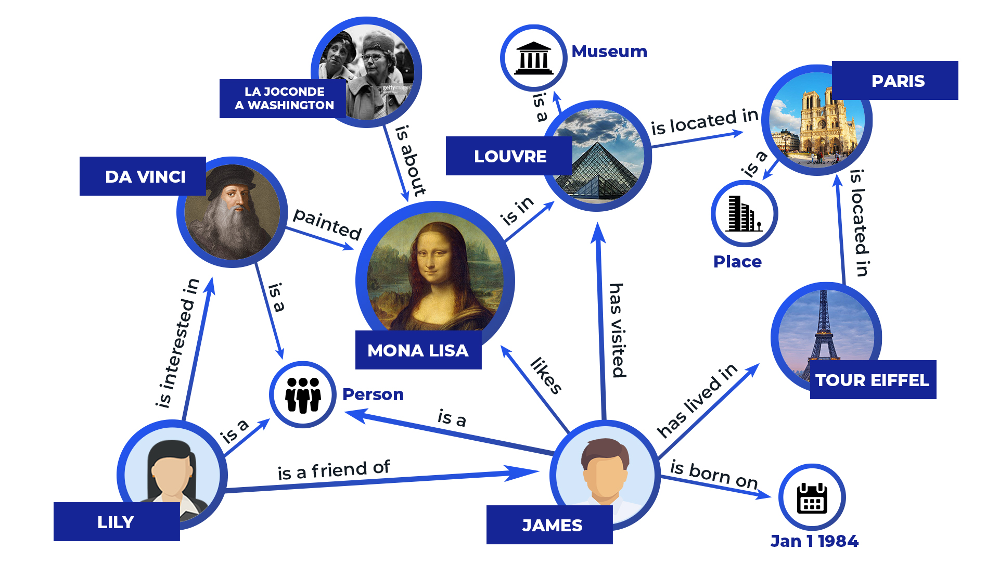
### 進化するAIと情報検索のなかで広がる「知識グラフ」

AI と情報検索はここ数年で大きく変わりました。単に「似ている文章を探す」だけではなく、**情報どうしのつながり**や**文脈の広がり**まで扱う必要が出てきたからです。ここで力を発揮するのが **知識グラフ（Knowledge Graph）** です。知識グラフは、データを「ノード（点）＝エンティティ」「エッジ（線）＝関係」で表すグラフ構造として保存し、物・出来事・状況・抽象的な概念まで、互いの**関係性**を含めて記述します。
この発想は人の考え方に近いです。私たちは事実をバラバラに覚えるのではなく、**関連づけたネットワーク**として理解します。たとえば「コーヒー」と聞くと、豆・焙煎・抽出方法・カフェイン・朝の習慣・カフェ文化…と、自然に関連が頭の中でつながります。知識グラフはこの**連想の網**を、機械にも扱える**構造**として表に出してくれます。

一方、従来の RAG（Retrieval-Augmented Generation）は**意味の近さ**でテキスト断片を引き当てるのが得意ですが、**広い話題をまたぐ質問**や**複数の文書をまたぐ推論（マルチホップ）**では、重要な関係が見えにくくなることがありました。**Knowledge Graph RAG（GraphRAG）** はここを改善します。先に**構造を作っておく**ことで、関係の道筋をたどれるようにし、質問に対して**どこを読めばよいか**をはっきりさせます。その結果、複雑な質問でも、**どの関係を通って答えに至ったのか**を説明しやすくなります。

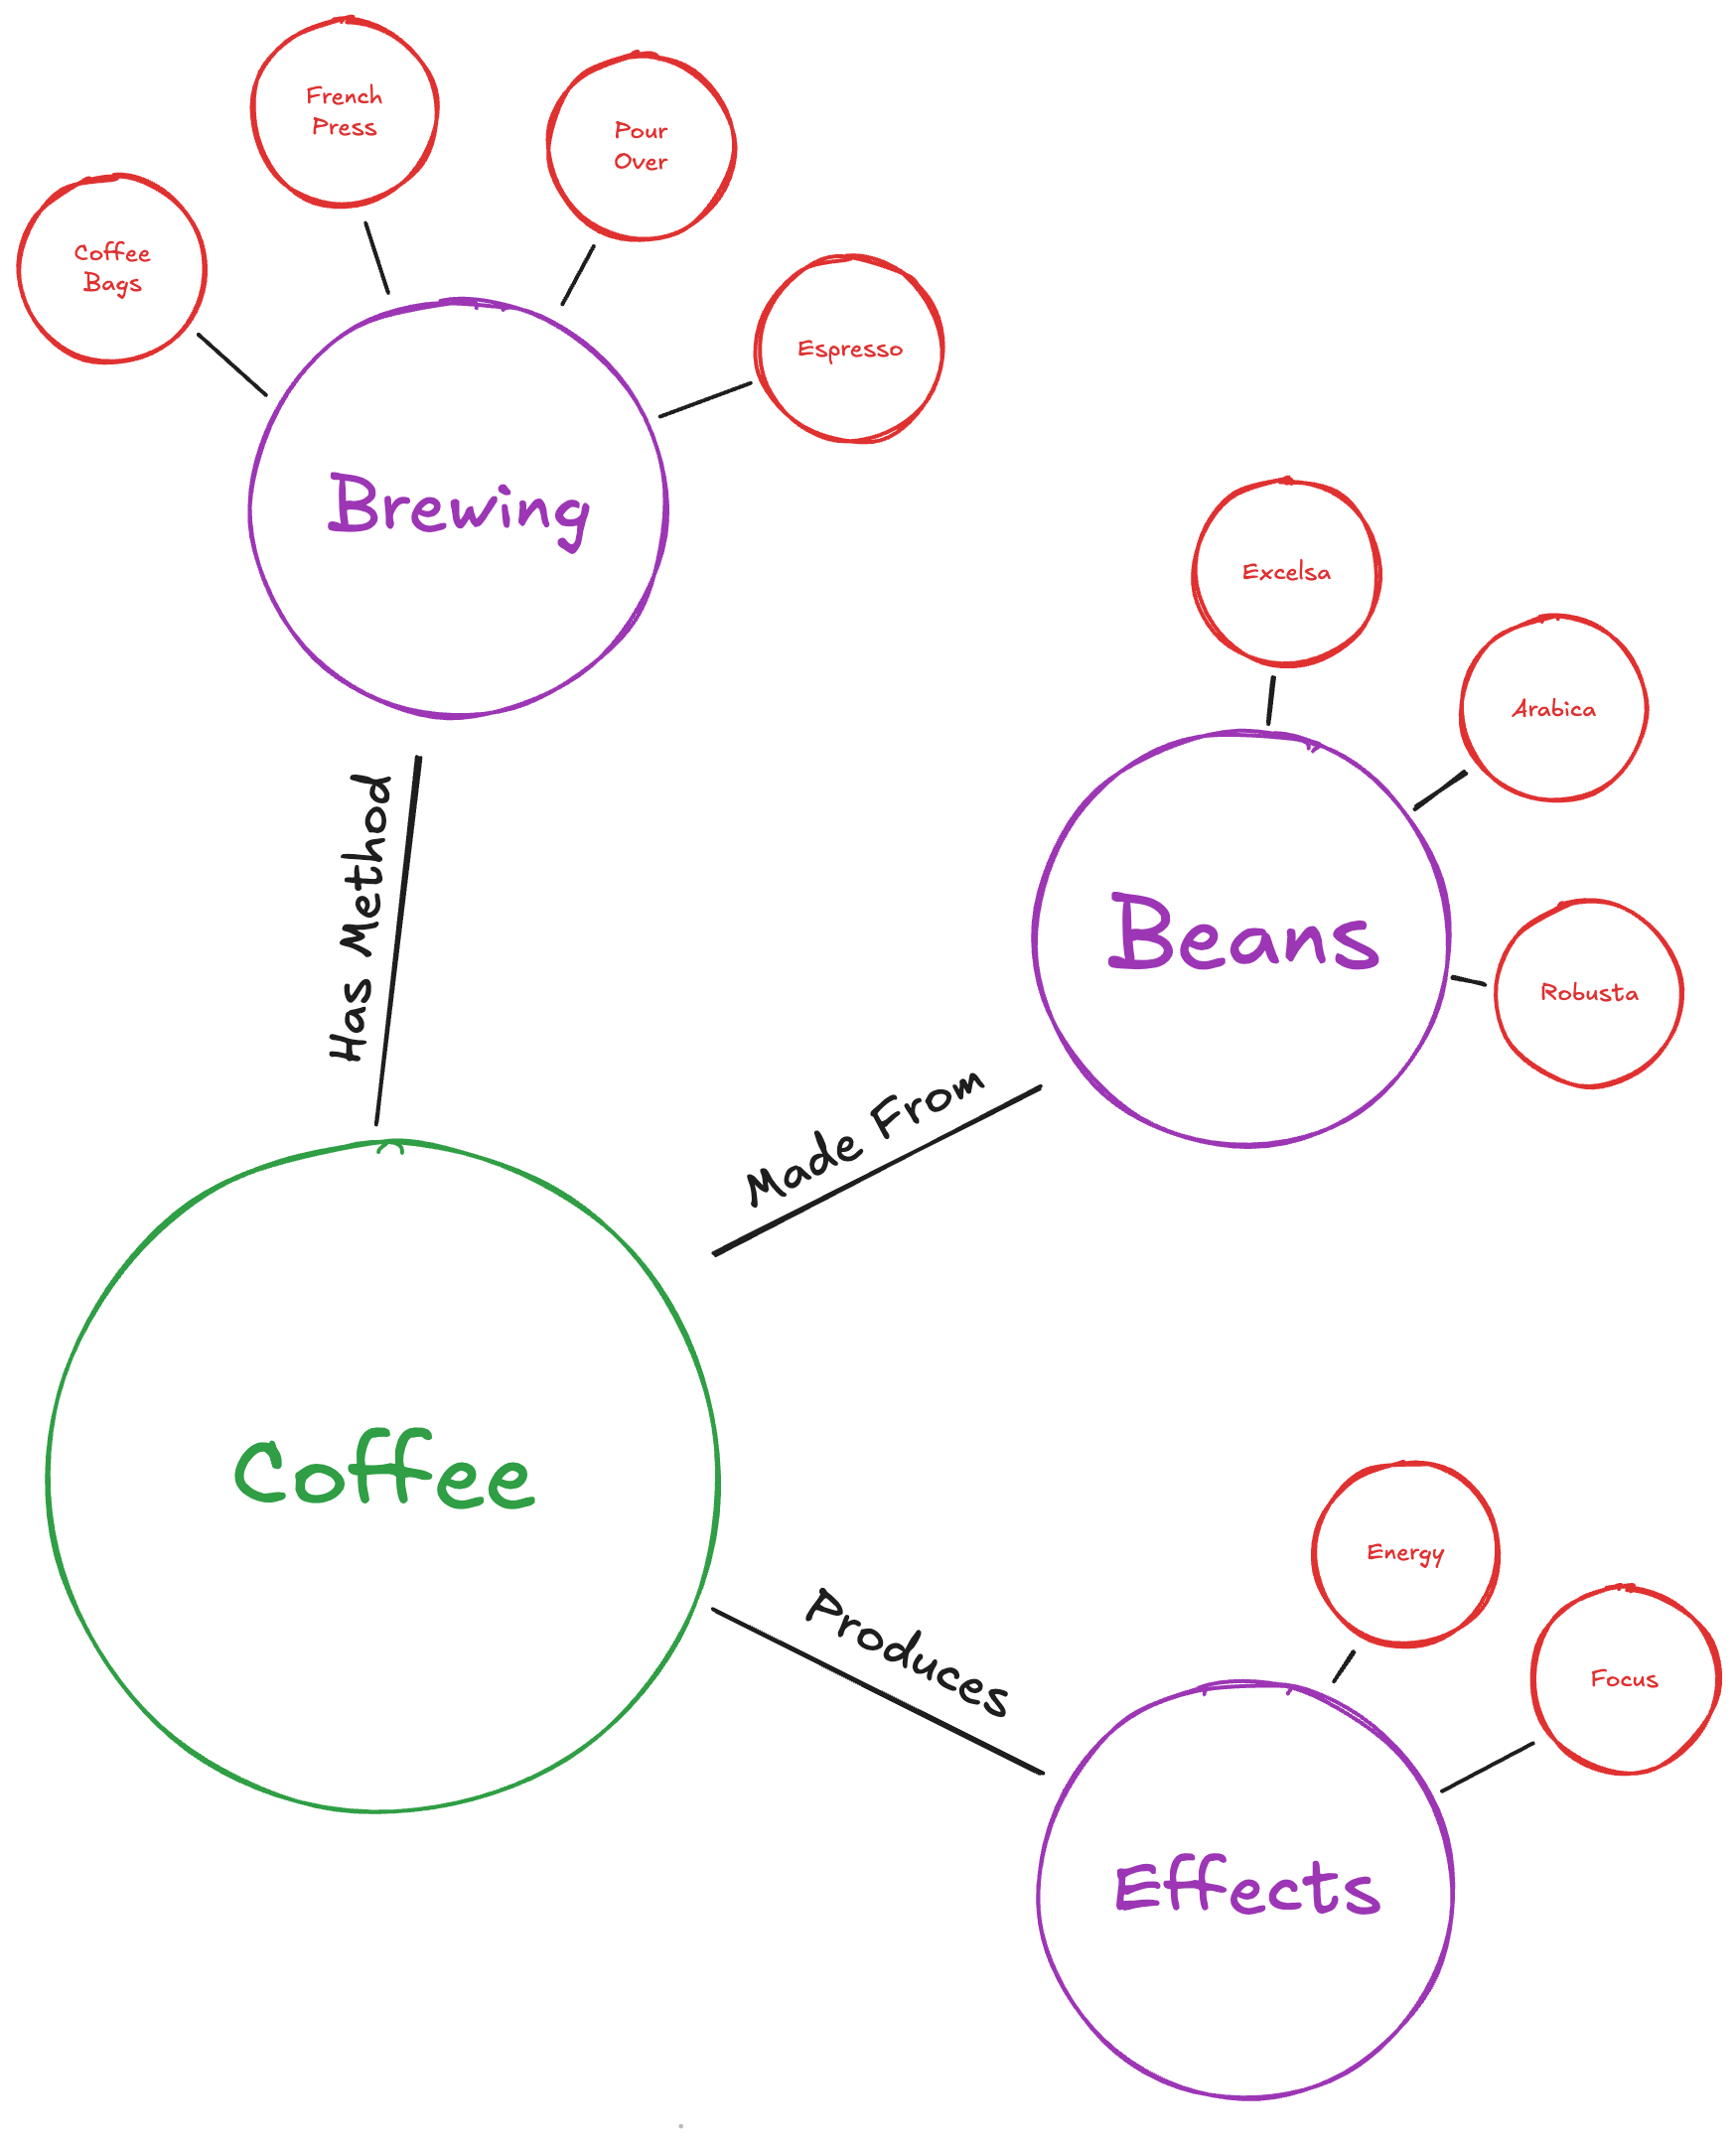

身近な直観のたとえ：「coffee（コーヒー）」という概念の網

「coffee」と聞くと、多くの人は “ただの飲み物” ではなく、豆（Arabica/Robusta）・焙煎（light/medium/dark）・抽出法（drip/espresso/press）・化学成分（caffeine/酸味/油分）・行動（morning routine/社交）・場所（café/office） などへ自然に連想が広がります。知識グラフはこの“頭の中のネットワーク”を機械が扱える 構造データ にします。知識グラフはこの“頭の中のネットワーク”を機械が扱える 構造データ にします。

---

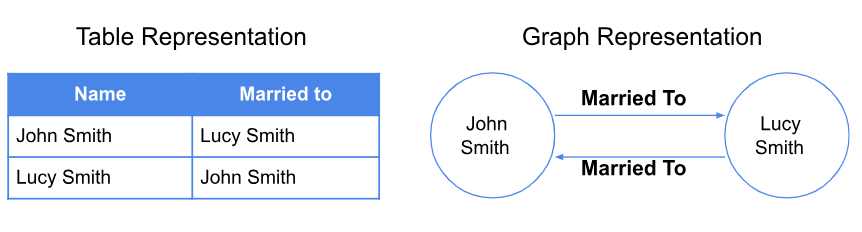

### 知識グラフ（KG）とは？

**知識グラフ（KG）** は、現実世界の**エンティティ（人・組織・場所・出来事・概念）**と、それらの**関係**をノードとエッジで表す**知識ベース**です。ポイントは、

* **テキストの意味**（説明文や属性）と
* **関係の骨組み**（誰と誰がどうつながるか）
  を**同時に**持てることです。
  これにより、「この概念とあの概念がどう関係しているのか」「いつ・どこで・誰が・何をしたのか」といった**構造的な問い**にも自然に答えやすくなります。

---

### LLM の登場で何が変わったか

昔は知識グラフを作るのに**多くの手作業**が必要でした。専門家が用語や関係を定義し、データベースから丹念に変換していくやり方です。これは正確ですが、**時間がかかり**、新しい領域へ広げるのも大変でした。
いまは **LLM（大規模言語モデル）** が登場し、**テキストから自動でエンティティや関係を抽出**できるようになりました。モデルが文章を理解し、必要なノードとエッジを取り出して、**半自動的に知識グラフを拡張**できます。新しい文献が増えても、追いついて更新しやすい。つまり、**スケール**と**継続運用**の面で現実的になったのです。

---

### 実例で確かめる：Microsoft の GraphRAG

この仕組みを自分たちで体験し、従来の**ベクトル類似検索（Vector RAG）**と比較するために、Microsoft のオープンソース実装 **GraphRAG** を使います。GraphRAG は、テキストから知識グラフを作り、**コミュニティ（話題の塊）**を階層的に検出し、**コミュニティ要約**を事前に作ります。質問のときは、この**グラフ＋要約＋原文**を組み合わせて答えます。Vector RAG が苦手な**全体俯瞰**や**多段の関係推論**で、GraphRAG の良さが分かりやすく出ます。

---

### 知識グラフの 3 つの主要要素

#### エンティティ（Entity）
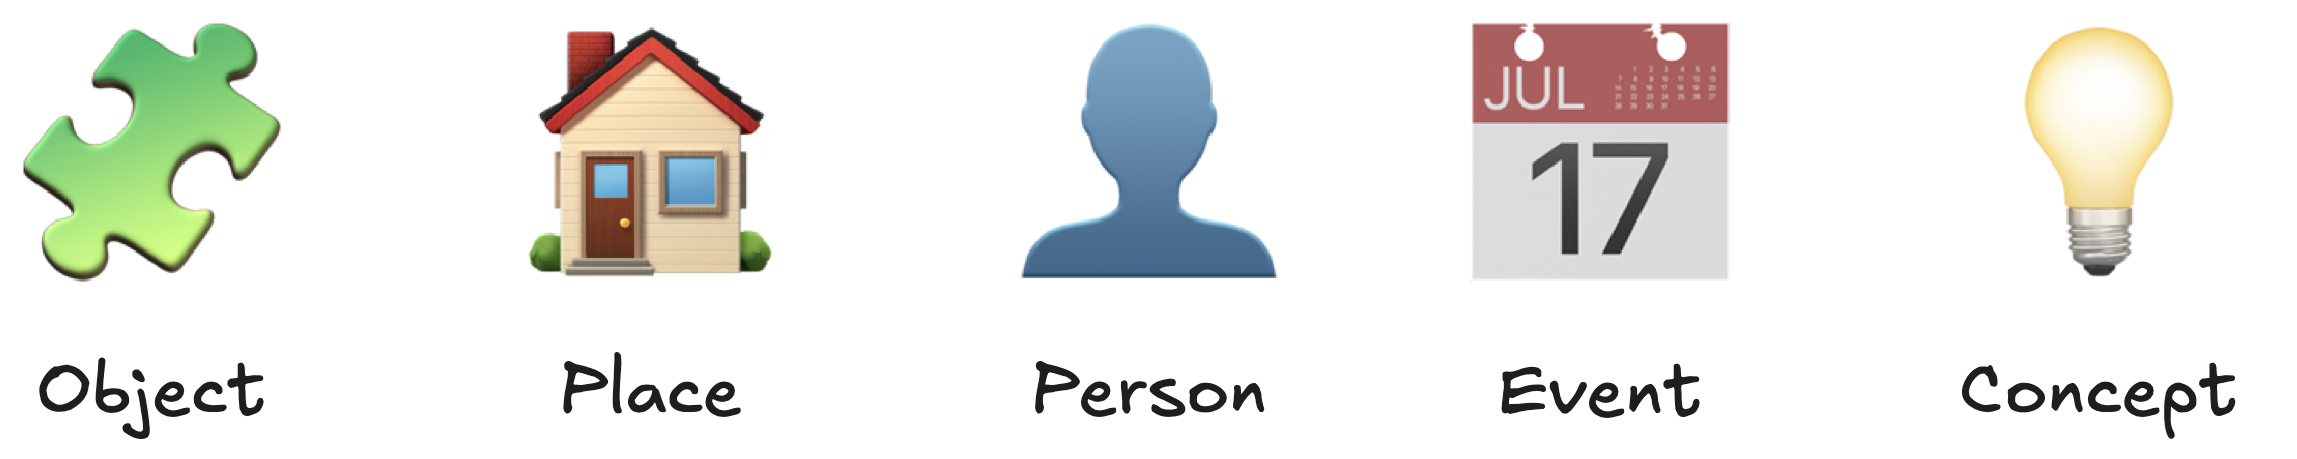

エンティティは、**人・場所・組織・出来事・概念**などの**固有の対象**です。テキストを LLM で分析して抽出し、**ノード**として登録します。別の文章で同じ対象が出てきたら、**重複をマージ**して一つのノードにまとめ、**複数の説明や別名**を持てるようにします。こうして、一つの対象に関する情報が**一箇所に集約**されます。

#### リレーション（Relationship）
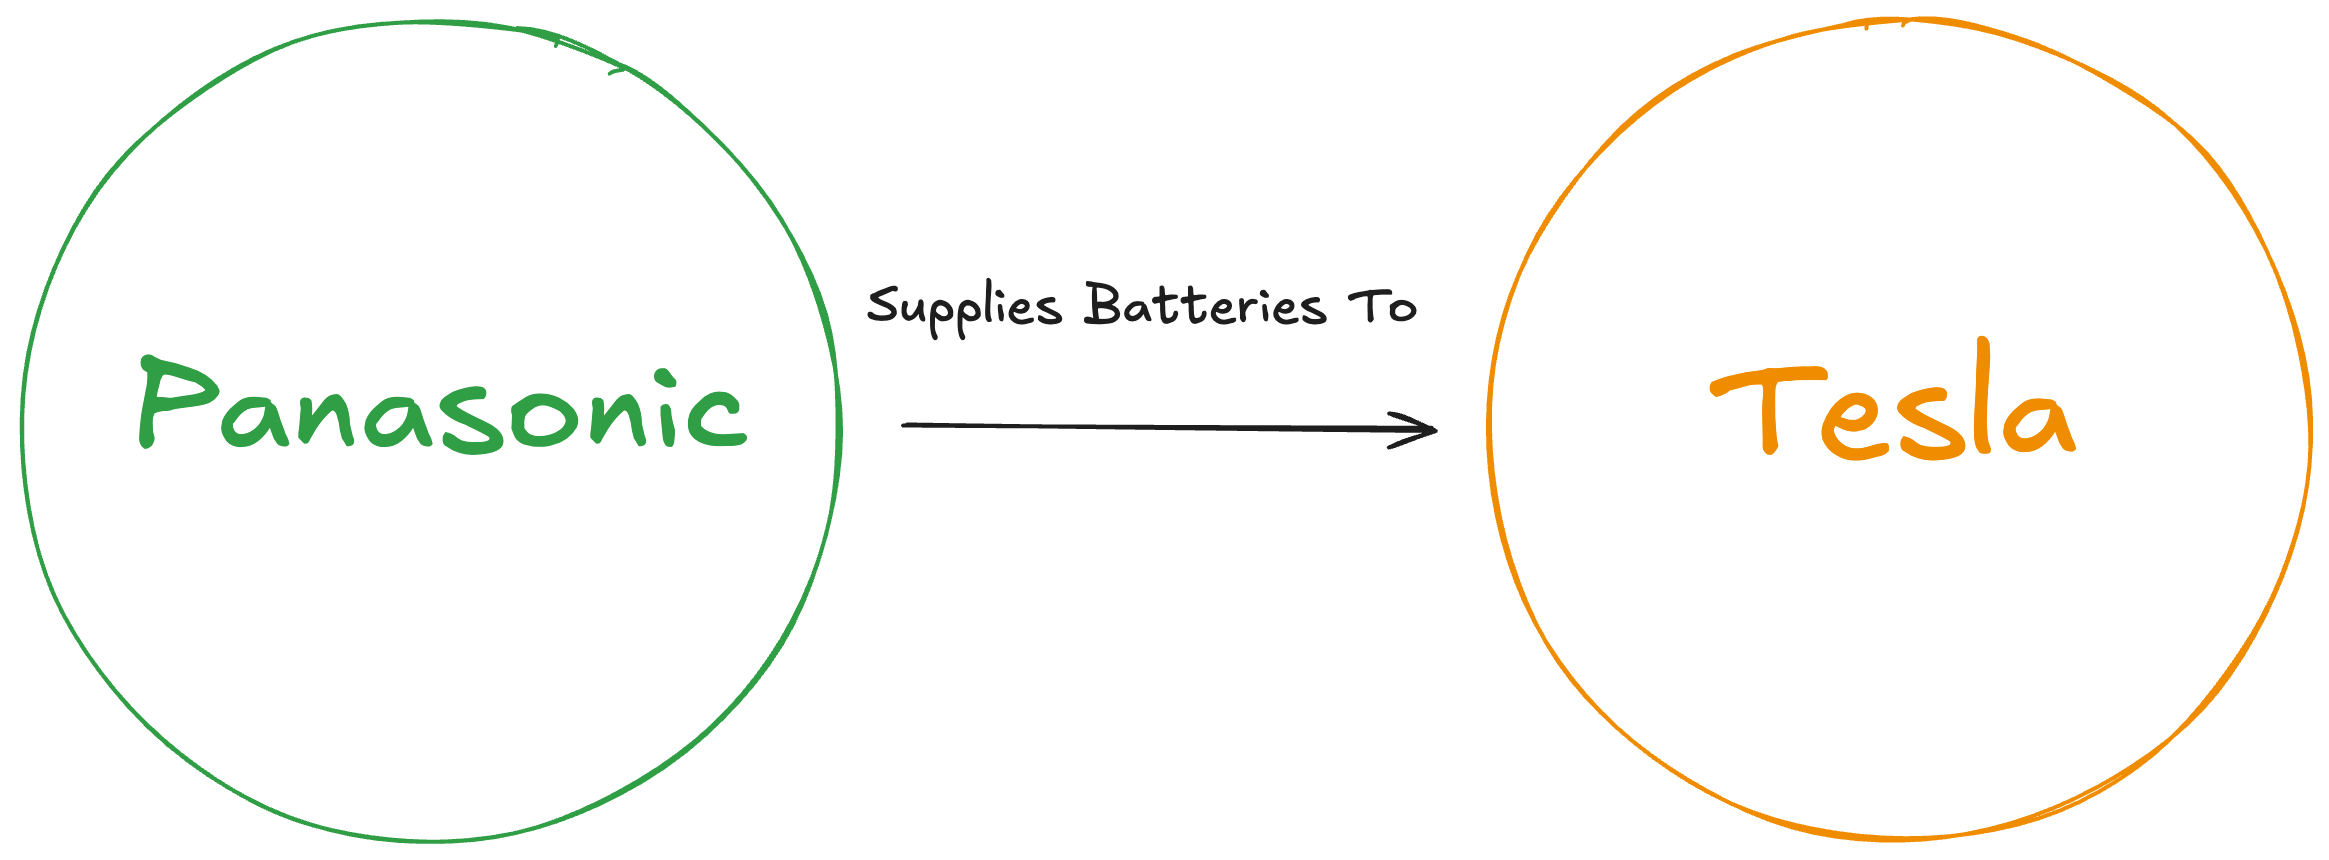

リレーションは、**2つのエンティティのつながり**を表す**エッジ**です。抽出時に「**誰（source）→誰（target）**」「**どんな関係**（親子・所属・因果・同一・位置・参加…）」を**短い説明つき**で保存します。重複する関係が見つかれば、説明を**統合**して、より**豊かな意味**を持つ一本のエッジに育てます。これにより、**関係の強さ**や**多面的な説明**が蓄積されていきます。

#### コミュニティ（Community）
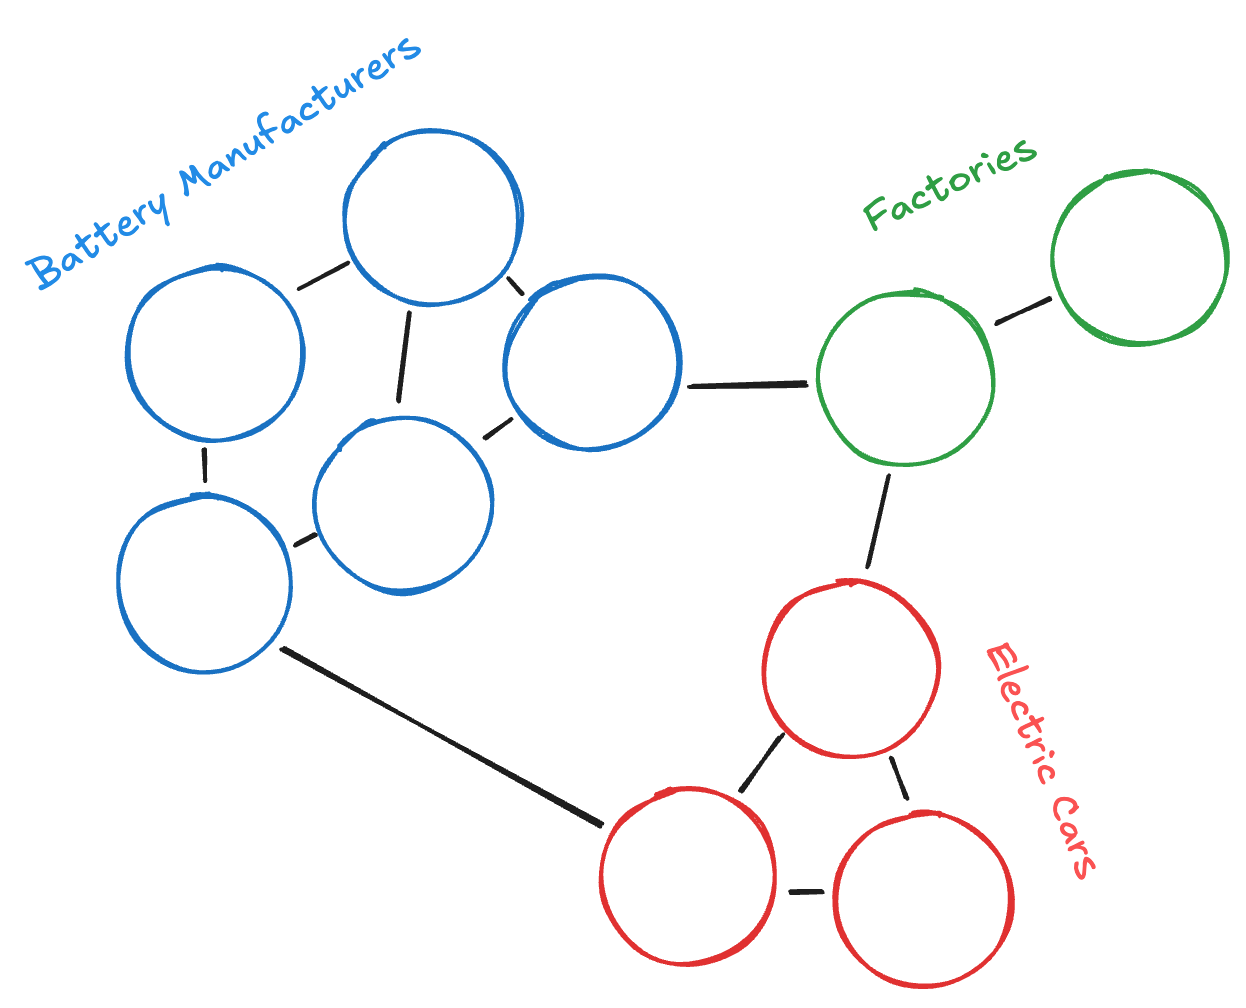

コミュニティは、**関連の強いエンティティと関係の集まり**です。グラフ上でアルゴリズム（例：**Leiden**）を使って自動的に見つけ、**上位はざっくり・下位は細かい**という**階層構造**を作ります。各コミュニティには LLM で**要約**を書き、**その塊の特徴・主要トピック・代表的な関係**を短く整理します。これが**地図の凡例**のような役割を果たし、質問のときに「どの塊から答えの材料を持ってくるか」を決めやすくします.

---

### GraphRAG の作成データフロー（Creation Data Flow）
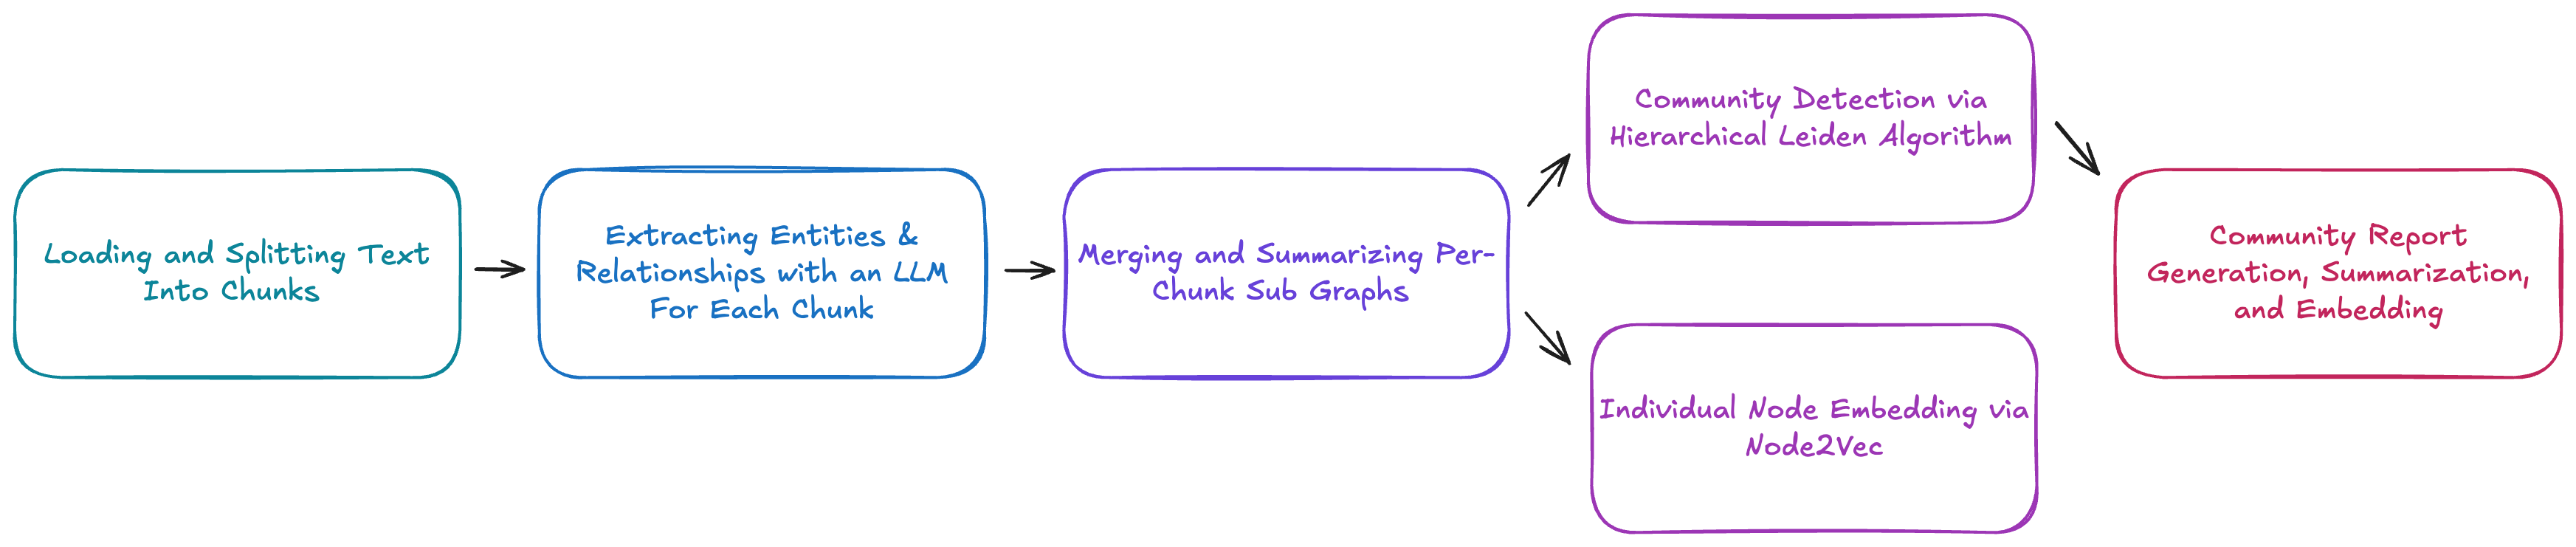

GraphRAG の **Indexing（作成）** は少し手間がかかりますが、順番はシンプルです。

1. **ドキュメント読み込み**
   まず対象のテキスト群を読み込みます（日本語なら UTF-8 推奨）。長文はそのままでは扱いにくいので、次のステップで扱いやすくします。

2. **チャンク分割（Chunking）**
   文章を**小さめの塊（Text Unit）**に分割します。これは後で「**どの部分から根拠を引いたか**」を示すためにも大切です。日本語はトークンが増えやすいので、**やや小さめのサイズ＋少しの重なり**から始めると安定します。

3. **サブグラフ作成（Chunk 内での抽出）**
   各チャンクに対して LLM で**エンティティとリレーション**を抽出し、**小さなグラフ（サブグラフ）**を作ります。ここでは**根拠となる原文への参照**も一緒に保存します。

4. **サブグラフの統合（全体グラフへ）**
   すべてのサブグラフを**一つの大きなグラフ**にまとめます。ここで**重複エンティティのマージ**や**重複リレーションの統合**を行い、**全体の一貫性**を整えます。

5. **コミュニティ検出（階層化）**
   グラフ全体を解析して、**話題の塊（コミュニティ）**を見つけます。**階層的**に分けることで、上位レベルでは**全体像**、下位レベルでは**詳細**をつかめるようになります。

6. **コミュニティ要約（レポート化）**
   各コミュニティについて、LLM に**短い要約**を書かせます。**主要なエンティティ、関係、ポイント、根拠リンク**などを入れておくと、後の検索で**素早く“当たり”をつける**助けになります。

7. **（必要に応じて）ベクトル化と保存**
   原文チャンクやコミュニティ要約、エンティティ説明などに**埋め込みベクトル**を付与し、**ベクトルDB**に保存します。これで、**構造（グラフ）**と**意味的近さ（ベクトル）**の両方を武器にできます。

> こうして、**原文テキスト**・**知識グラフ**・**コミュニティ要約**がそろいます。質問のときは、
> **（1）全体の塊から当たりをつける →（2）関係の近傍をたどる →（3）原文を引用して確証する**
> の流れで、**道筋のある答え**を組み立てられます。

---




##### 0. 前提（環境と準備）

* **Python**：公式推奨の通常環境（3.10+ 目安）。`pipx`/仮想環境の利用を推奨。
* **GraphRAG 本体**：`pip install graphrag` で CLI が入ります。
* **モデル鍵**：OpenAI などの API キー（`.env` に保存）。初期化コマンドで `.env` と `settings.yaml` が生成されます。初期化の仕様は公式「Init Command」参照。
* **動作の全体像**：生テキスト→知識グラフ抽出→コミュニティ階層化→コミュニティ要約→検索で活用、という段階的パイプラインです（公式トップの説明）。

---

##### 1. プロジェクトの作成と初期化

```bash
# 任意の作業フォルダへ
mkdir graphrag-ja && cd graphrag-ja

# 初期化（.env と settings.yaml、デフォルトのプロンプト一式を生成）
graphrag init --root .
```

* `graphrag init` は **.env** と **settings.yaml**、そして **LLM プロンプトの雛形** を所定ディレクトリに出力します。初期化の使い方は公式の `init` ページ通りです。

---

##### 2. ディレクトリ構成（出来上がる/用意するもの）

初期化後・インデックス後はおおむね下記のようになります（**太字**は特に触る/見る場所）：

```
graphrag-ja/
├─ .env                      # ← APIキーや環境変数（手で編集）
├─ settings.yaml             # ← 設定の本体（手で編集）
├─ input/                    # ← 日本語テキスト(.txt, UTF-8)を置く
├─ output/                   #   実行後に生成される成果物（Parquet等）
│   ├─ community_reports.parquet
│   ├─ entities.parquet
│   ├─ relationships.parquet
│   ├─ text_units.parquet
│   └─ ...（他にも表が出ます）
├─ cache/                    # LLM応答などのキャッシュ
├─ logs/                     # 実行ログ
└─ prompts/                  # 既定プロンプト（init が出力）
```

* 生成される **出力テーブル（Parquet）** は、知識モデルに対応しており、スキーマは公式「Outputs」にまとまっています（どの列が何を表すかの定義）。

---

##### 3. 日本語データの投入（エンコーディング注意）

* **input/** 配下に **UTF-8 の .txt** を置きます。Aozora など **Shift_JIS/CP932** の場合は事前に変換しましょう。
  例：`iconv -f CP932 -t UTF-8 original.txt > input/file_utf8.txt`
* ルビ（《…》や｜）が多い場合は軽く除去しておくと抽出が安定します（任意）。

---

##### 4. `.env` を設定（API キー）

`.env` は init 済みなので、中身を編集して鍵を入れます（変数名は `settings.yaml` で参照されます）：

```env
# 例（OpenAI）
GRAPHRAG_API_KEY=sk-xxxx...
OPENAI_API_KEY=${GRAPHRAG_API_KEY}
```

> `.env` の値は `settings.yaml` 内で `${ENV_VAR}` 参照できます（公式「Detailed Configuration」仕様）。([Microsoft GitHub][4])

---

##### 5. `settings.yaml` を日本語向けに調整

ポイントは **モデル**（多言語に強いもの）と **プロンプト言語**（日本語に差し替え）の2点。モデル選択・上書きは公式ガイドにまとまっています。
また、GraphRAG は「特定言語に最適化していない」ため、**日本語ではプロンプトを日本語化**し、**モデルも多言語強いもの**にするのが定石です（Issue の公式回答）。

変更例（抜粋）：

```yaml
models:
  default_chat_model:
    type: openai_chat
    auth_type: api_key
    api_key: ${GRAPHRAG_API_KEY}
    model: gpt-4o
    model_supports_json: true
  default_embedding_model:
    type: openai_embedding
    auth_type: api_key
    api_key: ${GRAPHRAG_API_KEY}
    model: text-embedding-3-large

input:
  storage:
    type: file
    base_dir: "input"
  file_type: text

chunks:
  size: 1000         # 日本語はトークン膨らみやすい→やや小さめ
  overlap: 120

extract_graph:
  model_id: default_chat_model
  prompt: "prompts_ja/extract_graph.txt"   # ← 日本語化したプロンプトに差し替え
  entity_types: [organization, person, location, event]
  max_gleanings: 2

extract_graph_nlp:
  text_analyzer:
    extractor_type: cfg   # 英語専用regexは避ける
  async_mode: threaded

community_reports:
  model_id: default_chat_model
  graph_prompt: "prompts_ja/community_report_graph.txt"
  text_prompt:  "prompts_ja/community_report_text.txt"
  max_length: 2000
  max_input_length: 8000

local_search:
  chat_model_id: default_chat_model
  embedding_model_id: default_embedding_model
  prompt: "prompts_ja/local_search_system_prompt.txt"

global_search:
  chat_model_id: default_chat_model
  map_prompt:      "prompts_ja/global_search_map_system_prompt.txt"
  reduce_prompt:   "prompts_ja/global_search_reduce_system_prompt.txt"
  knowledge_prompt:"prompts_ja/global_search_knowledge_system_prompt.txt"
```

> **補足**：Global / Local / DRIFT / Basic といった各 **検索モード** は CLI から選択します。Global は **コミュニティ要約を map-reduce** で使う「全体俯瞰向け」の方式です（詳細は公式クエリ解説）。

---

##### 6. 日本語プロンプトの用意（prompts_ja/）

`graphrag init` が出した `prompts/` の英語テンプレートを **prompts_ja/** にコピーし、**日本語化**します。
各プロンプトの末尾に次の一行を追加すると安定しやすいです：

> 出力は必ず日本語で、本文の短い引用による根拠を付け、箇条書きで簡潔にまとめてください。

（プロンプトを独自化しても CLI 仕様は変わりません。CLI は後述ページに集約されています。）([Microsoft GitHub][8])

---

##### 7. インデクシングの実行（Indexing）

```bash
# ルートを指定してインデックス作成
graphrag index --root .
```

* 公式の “Getting Started” でも、**index → query** の順で進めることが示されています。まずは index を回すのが基本です。([Microsoft GitHub][9])
* 実行が進むと **output/** に Parquet テーブルが並びます（`entities.parquet`、`relationships.parquet`、`community_reports.parquet` など）。テーブル仕様は「Outputs」を参照。

> 参考：インデクシング中は各段階で表が増えます。テキスト分割→抽出→統合→コミュニティ→要約…と段階的に **構造と要約** が揃います（各段で Parquet が出る説明は実務解説記事にもまとまっています）。

---

##### 8. ディレクトリの中身を理解する（出力の見方）

* **`output/entities.parquet`**：エンティティ（ノード）。別名や説明、出現ソースへの参照など。
* **`output/relationships.parquet`**：リレーション（エッジ）。`source`/`target`/`relation_type` と根拠スニペット。
* **`output/text_units.parquet`**：元テキストのチャンク。根拠の引用先。
* **`output/community_reports.parquet`**：コミュニティ要約。Global Search の材料。
* スキーマの正確な列名・型は **公式「Outputs」** の表を確認してください。

> （参考）クエリ時には、コミュニティ要約・エンティティ・リレーション・テキストユニットがロードされ、クエリの埋め込みとの類似度なども使いながら応答を合成します.
---
##### 9. クエリの実行（確認用）

インデクシング後、まずは **Global** を試すと「全体俯瞰」の威力が分かりやすいです。

```bash
# 例：グローバル検索（全体俯瞰の質問向け）
graphrag query --root . --method global --query "このコーパスの主要テーマを3つ、根拠付きで要約して"

# 例：ローカル検索（エンティティ中心の質問向け）
graphrag query --root . --method local --query "登場人物AとBの関係と、関連イベントを説明して"
```

* CLI のコマンド体系は公式の **CLI リファレンス** に一覧があります。
* **Global Search の動作**（コミュニティ要約をレベル指定で map-reduce）も公式ページで図解されています。

---

##### 10. 日本語での品質を上げるコツ（最初に効くもの）

* **モデル**：多言語に強いチャットモデル＋高性能な埋め込み（例：`gpt-4o` + `text-embedding-3-large`）。モデルを差し替える方法は「Language Model Selection」を参照。
* **プロンプト**：**完全日本語化**。出力言語と根拠（引用）の明示。
* **チャンク設計**：`size ~ 900–1000 / overlap ~ 120–150` を起点に。
* **抽出器**：英語専用の `regex_english` は避け、`cfg` か **LLM 抽出一本**で。
* **言語に関する注意**：GraphRAG 自体は特定言語に最適化していないため、**プロンプトとモデルの選定で差が出る**ことを公式 Issue でも認めています。

---

**テキストの読み取りと分割**
この例では、夏目漱石の『こころ』を使用します。

これはテキストファイル（索引、用語集、参考文献は削除）として読み込まれ、1000トークンと120トークンの重複チャンクに分割されます。

In [20]:
from langchain_text_splitters import TokenTextSplitter

with open('./file/input/kokoro_utf8.txt', 'r') as file:
    content = file.read()
    
text_splitter = TokenTextSplitter(chunk_size=1200, chunk_overlap=200)

texts = text_splitter.split_text(content)

In [21]:
len(texts)

273

エンティティとリレーションシップの抽出プロンプト

これは、実際のGraphRAG実装で使用される、調整されたエンティティ抽出プロンプトです。この形式で抽出することで、何が起こっているかを確認できます。

In [22]:

from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

import os

load_dotenv('file/.env')
API_KEY = os.getenv('GRAPHRAG_API_KEY')
llm = ChatOpenAI(temperature=0.0, model="gpt-4o", api_key=API_KEY)
prompt_template = """
-目的（Goal）-
与えられたテキストと、抽出対象エンティティ種別のリストに基づき、該当するすべてのエンティティと、それらの間の関係を抽出してください。

-手順（Steps）-
1. エンティティの同定：
  各エンティティについて以下を抽出：
  - entity_name：エンティティ名（大文字）
  - entity_type：[{{entity_types}}] のいずれか
  - entity_description：属性や活動の包括的説明
  出力形式：
  ("entity"{{tuple_delimiter}}<entity_name>{{tuple_delimiter}}<entity_type>{{tuple_delimiter}}<entity_description>)

2. 関係の同定：
  ステップ1で同定したエンティティのうち、**明確に関連** している (source_entity, target_entity) の組を抽出。
  各関係について：
  - source_entity：ソース側エンティティ名
  - target_entity：ターゲット側エンティティ名
  - relationship_description：関連があると判断した理由の説明
  - relationship_strength：関係強度の数値スコア
  出力形式：
  ("relationship"{{tuple_delimiter}}<source_entity>{{tuple_delimiter}}<target_entity>{{tuple_delimiter}}<relationship_description>{{tuple_delimiter}}<relationship_strength>)

3. 出力は英語で、上記レコードを **{{record_delimiter}}** で連結した単一リストとして返してください。

4. 終了時に {{completion_delimiter}} を出力してください。

######################
-例（Examples）-
（原文の例を保持）

######################
-実データ（Real Data）-
Entity_types: {{entity_types}}
Text: {input_text}
######################
Output:
"""


prompt = ChatPromptTemplate.from_template(prompt_template)

chain = prompt | llm | StrOutputParser()

### **最終的なEntity and Relationship を表示する**

In [25]:
import pandas as pd

entities = pd.read_parquet('file/output/entities.parquet')

entities.head()

,id,human_readable_id,title,type,description,text_unit_ids,frequency,degree,x,y
0,fc01f370-84a8-4d18-a5fd-1e4b33bad613,0,NATSUME SOSEKI,PERSON,NATSUME SOSEKI was a distinguished Japanese au...,[4f5bcfceca4c6bab7817e0a94ddf2be98705a4781d0f5...,2,2,0.0,0.0
1,c18189dd-7ffb-413c-9282-3dc3fd4ad930,1,KAMAKURA,GEO,"KAMAKURA is a city located in Japan, renowned ...",[4f5bcfceca4c6bab7817e0a94ddf2be98705a4781d0f5...,2,5,0.0,0.0
2,bda00f3c-2023-4b32-8972-6030b54f2fef,2,THE FRIEND,PERSON,A friend of the narrator who invited him to Ka...,[4f5bcfceca4c6bab7817e0a94ddf2be98705a4781d0f5...,1,4,0.0,0.0
3,226a6930-2647-494b-9d18-78d709352a47,3,THE NARRATOR,PERSON,THE NARRATOR is the central figure in the stor...,[4f5bcfceca4c6bab7817e0a94ddf2be98705a4781d0f5...,7,25,0.0,0.0
4,fd17edc2-b274-4429-b0b7-fc5ddb89e10d,4,SENSEI,PERSON,SENSEI is a central and enigmatic figure in th...,[4f5bcfceca4c6bab7817e0a94ddf2be98705a4781d0f5...,15,32,0.0,0.0


In [26]:
import pandas as pd

relationships = pd.read_parquet('file/output/relationships.parquet')

relationships.tail()

,id,human_readable_id,source,target,description,weight,combined_degree,text_unit_ids
480,2e0c203f-9a4f-415f-a360-0217c34a52dd,480,KOKORO,AOZORA BUNKO,Aozora Bunko made the text file of 'Kokoro' av...,0.85,8,[0a6c947ed3c6ea85afbddf1b32a2a36ef8169c25008f7...
481,22246d26-92eb-4e52-8573-e0077d5f36df,481,ASAHI SHIMBUN,NATSUME SOSEKI,Asahi Shimbun serialized the novel written by ...,1.00,4,[0a6c947ed3c6ea85afbddf1b32a2a36ef8169c25008f7...
482,cec8d9de-a466-48f8-8f8b-8f782e0a2c34,482,IWANAMI SHOTEN,SHUEISHA,Both are publishers involved in the distributi...,0.60,6,[0a6c947ed3c6ea85afbddf1b32a2a36ef8169c25008f7...
483,20b41cf2-cd17-4d8c-8a13-ac79290c4f5b,483,IWANAMI SHOTEN,AOZORA BUNKO,Both are involved in the distribution and corr...,1.00,6,[0a6c947ed3c6ea85afbddf1b32a2a36ef8169c25008f7...
484,a1bff30f-85fb-4fd3-9ffd-4ed9c055d210,484,AOZORA BUNKO,SHUEISHA,Both are involved in the distribution of 'Koko...,0.60,6,[0a6c947ed3c6ea85afbddf1b32a2a36ef8169c25008f7...


### Community Detection & Node Embedding
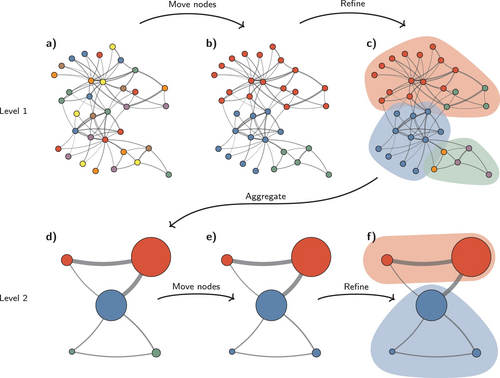
基本的なグラフ（エンティティとリレーション）ができたら、その構造を2つの方法で分析します。
**コミュニティ検出**では [**Leiden Algorithm**](https://en.wikipedia.org/wiki/Leiden_algorithm)を用いて明示的なグルーピングを見つけ、関連エンティティの階層構造を作ります。階層が下がるほど、コミュニティはより細かな粒度になります。
**ノード埋め込み**では [**Node2Vec**](https://arxiv.org/abs/1607.00653) を使い、各エンティティをベクトル表現に変換して、グラフ構造に潜む暗黙的な関係を捉えます。

この2つは補完的で、コミュニティによって**明らかなつながり**を、埋め込みによって**微妙なパターン**を理解できます。
これらをリレーション情報と統合することで、最終的な**ノード集合**が得られます。


In [27]:
import pandas as pd

nodes = pd.read_parquet('file/output/communities.parquet')

nodes.tail()

,id,human_readable_id,community,level,parent,children,title,entity_ids,relationship_ids,text_unit_ids,period,size
40,17c796fe-6e38-4da8-a349-d8c7b159bb1f,40,40,1,9,[],Community 40,"[aab8d102-ad85-4e5c-b646-4cbae33dc377, 39a8472...","[38f90fd4-a601-4318-8f2c-c94ab0b9b648, 3e27737...",[849b37a6d4961f9f9aad0afd1efb01b06b05fa706d6fc...,2025-10-03,7
41,faf48f00-f917-43bc-a657-8d97a86fcf07,41,41,2,16,[],Community 41,"[3cb0d035-de5a-437e-8127-41345906dce1, a273bdd...","[014b5ee6-dc8e-4b07-9ca9-edcccb744839, 0841bed...",[05897961baa9be6b4377e7c09424a9c04746d7a0e3f7c...,2025-10-03,34
42,765e9f18-7667-40dc-be52-cd34468e16d8,42,42,2,16,[],Community 42,"[7fb123e3-5ebe-4c5c-be7c-548e8601f25b, d5f9e90...",[5d0428f3-ad24-4571-b1fc-87cafbf7ca91],[a714f0da060926f8020454b2811b25aa767d8d21cf773...,2025-10-03,2
43,00afd5d4-bc6e-4679-99dc-204522f55773,43,43,2,38,[],Community 43,"[9d89d995-ac8e-4c16-8ea8-c8a5214bd582, fd17edc...","[00c88fde-6ecf-4730-b7ec-714c23044dcb, 0f2e23f...",[0a40fdfa5ec38923abf5c26b795fb4e745fa8721058e0...,2025-10-03,13
44,758d0b22-4523-4492-8fe4-dafc4dfd3654,44,44,2,38,[],Community 44,"[b098c916-795f-43c7-89c9-8445ac46e71e, c30cc70...",[d0859b0a-385a-480f-8ca9-38967e9b11fa],[30b302b8c030cd44a043204eacd5597c86b65af2ac420...,2025-10-03,2


コミュニティの明確なグループ化ができたので、階層的なノードコミュニティ全体の主要概念を集約し、さらに生成ステップと、その要約の簡潔な要約を作成できます。ノードと同様に、これらの要約も埋め込みモデルに通され、ベクトルストアに保存されます。

In [28]:
import pandas as pd

community_reports = pd.read_parquet('file/output/community_reports.parquet')

community_reports.tail()

,id,human_readable_id,community,level,parent,children,title,summary,full_content,rank,rating_explanation,findings,full_content_json,period,size
40,04ded97b4ada496e9f2f6451d8110d35,5,5,0,-1,"[28, 29, 30, 31]",Tokyo Community: Key Historical and Cultural E...,This report explores the interconnected entiti...,# Tokyo Community: Key Historical and Cultural...,7.5,The community's impact is significant due to i...,[{'explanation': 'General Nogi Maresuke is a p...,"{\n ""title"": ""Tokyo Community: Key Historic...",2025-10-03,15
41,68eeade0a64d47928103277b633caf86,6,6,0,-1,"[32, 33]",UENO Community: Interpersonal Dynamics and Ref...,The UENO community is characterized by complex...,# UENO Community: Interpersonal Dynamics and R...,7.5,The community's impact is significant due to t...,[{'explanation': 'UENO is depicted as a multif...,"{\n ""title"": ""UENO Community: Interpersonal...",2025-10-03,21
42,7573234db551435dacf2e559de5197e3,7,7,0,-1,[],Academic Community: Professor and Main Character,This report examines the academic community in...,# Academic Community: Professor and Main Chara...,7.5,The community has a significant impact due to ...,[{'explanation': 'The Professor is described a...,"{\n ""title"": ""Academic Community: Professor...",2025-10-03,4
43,5aad19e8cdfe40d9b53711fde61edd0c,8,8,0,-1,"[34, 35, 36, 37]",Community of the Teacher and Associated Entities,This report explores the community centered ar...,# Community of the Teacher and Associated Enti...,7.5,The community has a significant impact due to ...,"[{'explanation': 'The Teacher, referred to as ...","{\n ""title"": ""Community of the Teacher and ...",2025-10-03,20
44,8dd53702d8f64b8dadc7af9c313f0c82,9,9,0,-1,"[38, 39, 40]",Sensei and His Household,"The community revolves around Sensei, a centra...",# Sensei and His Household\n\nThe community re...,7.5,The community's impact is significant due to t...,[{'explanation': 'Sensei serves as a mentor to...,"{\n ""title"": ""Sensei and His Household"",\n ...",2025-10-03,29


In [29]:
print(community_reports['full_content'][0])

# K and His Complex Relationships

The community revolves around K, a deeply introspective individual with a complex web of relationships that significantly impact those around him. K's life is marked by personal and familial challenges, intellectual pursuits, and a tragic end. His connections with entities such as OJOUSAN, the narrator, and his family members highlight the intricate dynamics within this community. The relationships are characterized by emotional depth, cultural influences, and significant life events, culminating in K's suicide, which leaves a lasting impact on the community.

## K's introspective nature and philosophical interests.

K is depicted as a quiet and introspective individual, deeply engaged in philosophical and religious discussions. His background as the son of a Shinshu Buddhist monk and his interest in various religious texts, including Christianity and the Quran, highlight his intellectual curiosity [Data: Entities (158); Relationships (303, 314, 315)]

In [30]:
print(community_reports["summary"][0])

The community revolves around K, a deeply introspective individual with a complex web of relationships that significantly impact those around him. K's life is marked by personal and familial challenges, intellectual pursuits, and a tragic end. His connections with entities such as OJOUSAN, the narrator, and his family members highlight the intricate dynamics within this community. The relationships are characterized by emotional depth, cultural influences, and significant life events, culminating in K's suicide, which leaves a lasting impact on the community.


### GraphRAG Retrieval 
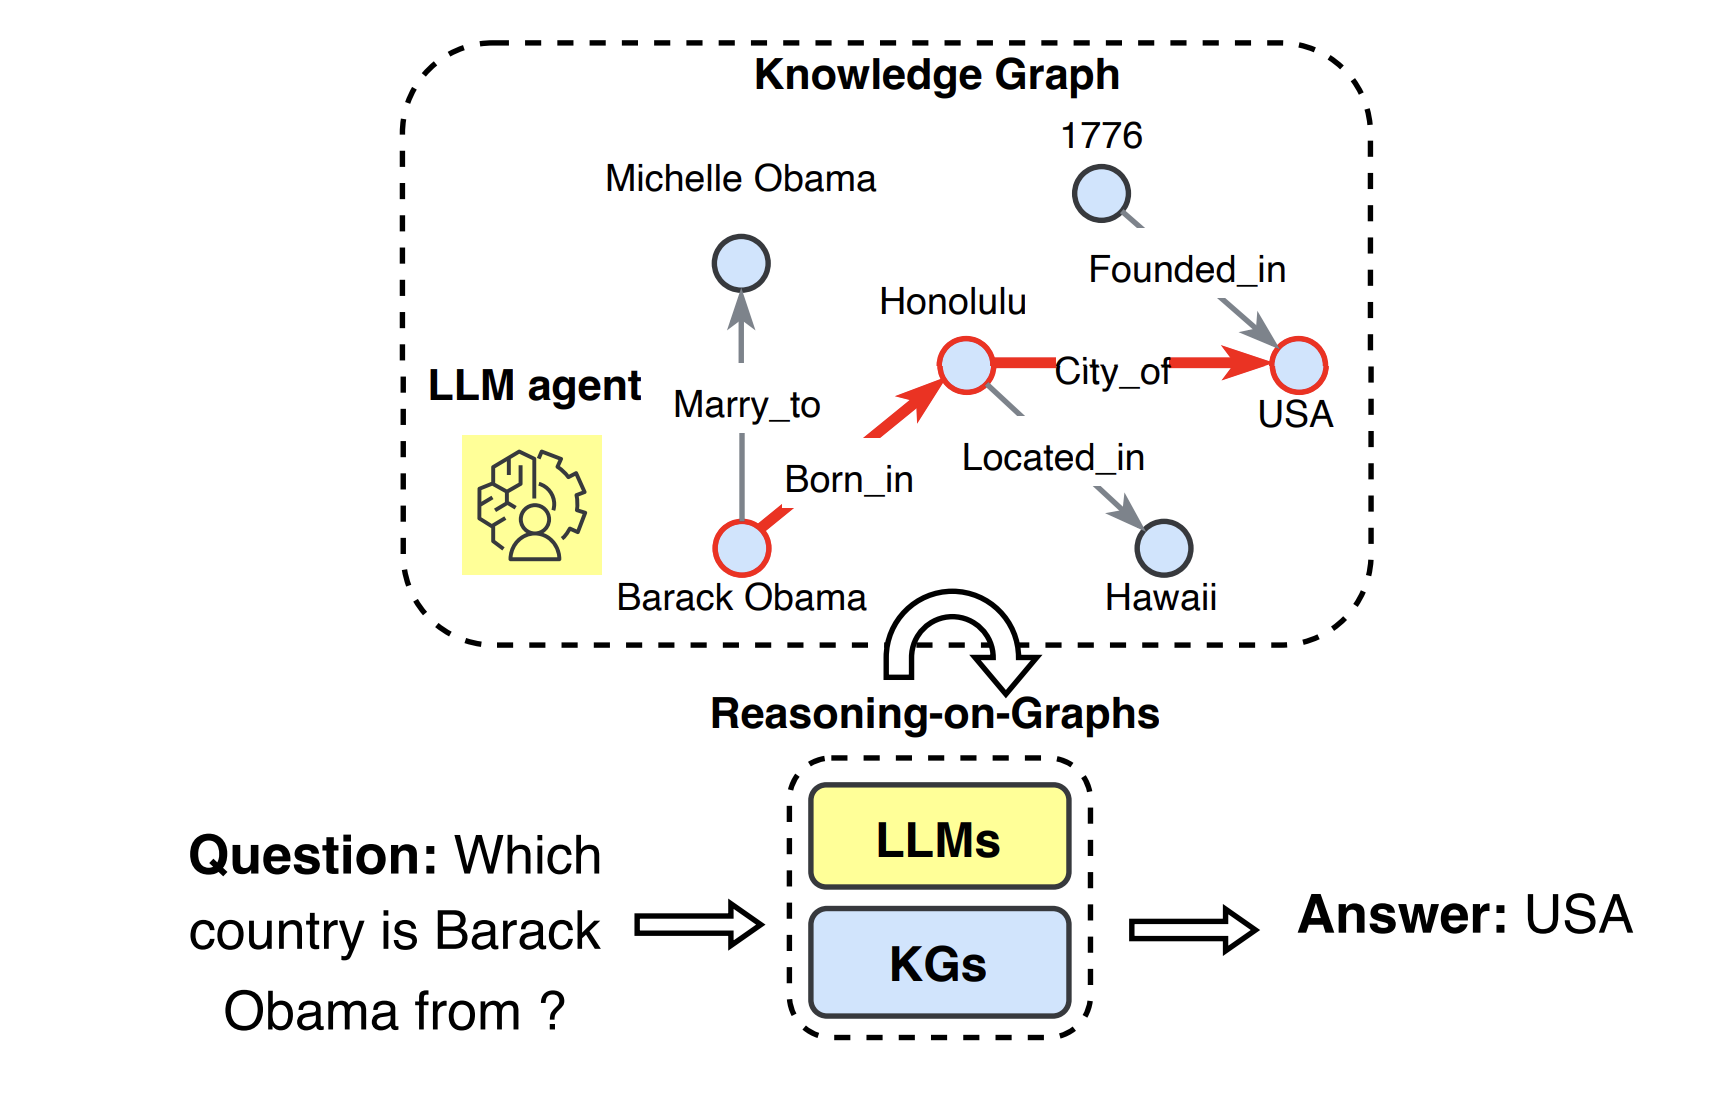

知識グラフを構築し、階層的なコミュニティを定義することで、**グラフ構造**と**コミュニティ階層の多段の粒度**を活用した複数の検索手法を実行できます。具体的には次のとおりです。

* #### **グローバル検索（Global Search）**

  **定義（拡張）**：グラフのコミュニティ階層（例：レベル0〜2など）から、**LLM が生成したコミュニティレポート**を収集し、マップリデュース的に要点抽出→統合要約→最終回答を行う手法。**広いテーマ横断の網羅性**と**高い可読性**を重視する。
  **入力**：ユーザ質問、参照するコミュニティ階層（例：`community_level=2`）、レポート埋め込み索引。
  **出力**：複数コミュニティの重要点を束ねた、**俯瞰的かつ整合的**な回答。
  **強み**：

  * 文書全体の**主要テーマの統合**に強い（背景整理・概論・サーベイ）。
  * チャンク境界を越えた**重要点の蒸留**ができる。
    **限界／注意**：
  * 細部の根拠（原文スニペットや具体的引用）には弱くなりやすい。
  * レベルが高すぎると抽象度が上がりすぎ、具体的質問にやや不向き。
    **使いどころ**：背景説明、関連テーマの横断比較、「まず全体像が欲しい」ケース。

* #### **ローカル検索（Local Search）**

  **定義（拡張）**：**セマンティック検索**で見つけた近傍の**エンティティ**や**関係**、それに紐づく**原文チャンク**や**コミュニティ要約**を収集・再ランクし、**具体的根拠**を重視して回答を生成する手法。**入口エンティティ→関係→周辺テキスト**という狭域トラバースを行う。
  **入力**：ユーザ質問、ベクタ近傍のエンティティ／チャンク、関係エッジ、（必要に応じて）対応コミュニティの短縮要約。
  **出力**：**根拠密度の高い**説明（具体的因果・登場人物相互作用・引用断片など）。
  **強み**：

  * 「誰→誰→なぜ」など**関係経路に基づく説明**が得意。
  * **事実確認・引用**や、設問に対する**ピンポイント回答**に強い。
    **限界／注意**：
  * 入口がずれると、狭い範囲の最適化で的外れになりやすい。
  * クエリが曖昧な場合は前処理（HyDE/言い換え）を併用すると安定。
    **使いどころ**：根拠提示が必須のQA、登場人物や概念の**具体的相互作用**の説明、**因果**の特定。

* #### **ドリフト検索（Drift Search）**

  **定義（拡張）**：[**HyDE**](https://arxiv.org/pdf/2212.10496)（仮想文書生成）でクエリを増強し、**関連コミュニティを推定**→**軽量グローバル要約（primer）**→そこから派生した**後続質問**ごとに**ローカル検索を反復**する、**柔軟トラバーサル＋動的推論**の手法。**グローバル×ローカル**を循環的に統合する。
  **入力**：ユーザ質問、HyDE で作る仮想文書、関連コミュニティ候補、反復回数（例：2イテレーション）。
  **出力**：質問・回答の**階層ツリー**（重要度でランク付け）と最終要約。
  **強み**：

  * 初期クエリが曖昧でも**探索しながら軌道修正**できる。
  * **テーマ漂流**（意図の拡張・深掘り）に強く、**未知領域の発見**がしやすい。
    **限界／注意**：
  * 反復により**コストとレイテンシ**が増えやすい。
  * 収束条件（反復回数・停止規則）を調整しないと冗長化する。
    **使いどころ**：問いが広い／曖昧、切り口が定まらない調査、**発散→収束**を要するリサーチ系QA。

---

### GraphRAG 検索関数

**注**：簡潔な例とするため、ライブラリではなく [**GraphRAG の CLI ツールを関数でラップ**](https://microsoft.github.io/graphrag/cli/)しています。したがって、ノートブックは**同一の GraphRAG 環境／カーネル**上で実行する必要があります。



In [ ]:
import subprocess
import shlex
from typing import Optional

def query_graphrag(
    query : str,
    method: str='global',
    root_path: str='./file',
    timeout: Optional[int] = None,
    community_level: int=2,
    dynamic_community_selection: bool = False
) -> str :
    """
    GraphRAG の CLI ツールを用いてクエリを実行します。

    引数:
        query (str): 処理するクエリ文字列
        method (str): クエリ方式（例: "global", "local", "drift"）
        root_path (str): ルートディレクトリへのパス
        timeout (int, optional): コマンド実行のタイムアウト秒数
        community_level (int): Leiden によるコミュニティ階層のレベル（デフォルト: 2）
        dynamic_community_selection (bool): グローバル検索で動的コミュニティ選択を使用するか（デフォルト: False）

    戻り値:
        str: GraphRAG からの出力

    例外:
        subprocess.CalledProcessError: コマンドが失敗した場合
        subprocess.TimeoutExpired: コマンドがタイムアウトした場合
        ValueError: community_level が負の値の場合
    """

    if community_level < 0:
        raise ValueError("Community Level Must be non-negative")
    
    command = [
        'graphrag', 'query',
        '--root', root_path,
        '--method', method,
        '--query', query,
        '--community-level', str(community_level)
    ]
    if dynamic_community_selection:
        command.append('--dynamic-community-selection')
    try:
        result = subprocess.run(
            command,
            capture_output=True,
            text=True,
            timeout=timeout
        )
        
        result.check_returncode()
        
        return result.stdout.strip()
    
    except subprocess.CalledProcessError as e:
        error_message = f"Command failed with exit code {e.returncode}\nError: {e.stderr}"
        raise subprocess.CalledProcessError(
            e.returncode,
            e.cmd,
            output=e.output,
            stderr= error_message
        )

In [32]:
query = """
『こころ』のテキストに基づいて、Kが自殺した主な動機と、その決断が「先生」「先生」「語り手」にどのような影響を与えたかを説明してください。

本文のみに基づき、外部の情報は一切用いず、日本語で回答してください。
"""


### ローカル検索（Local Search）
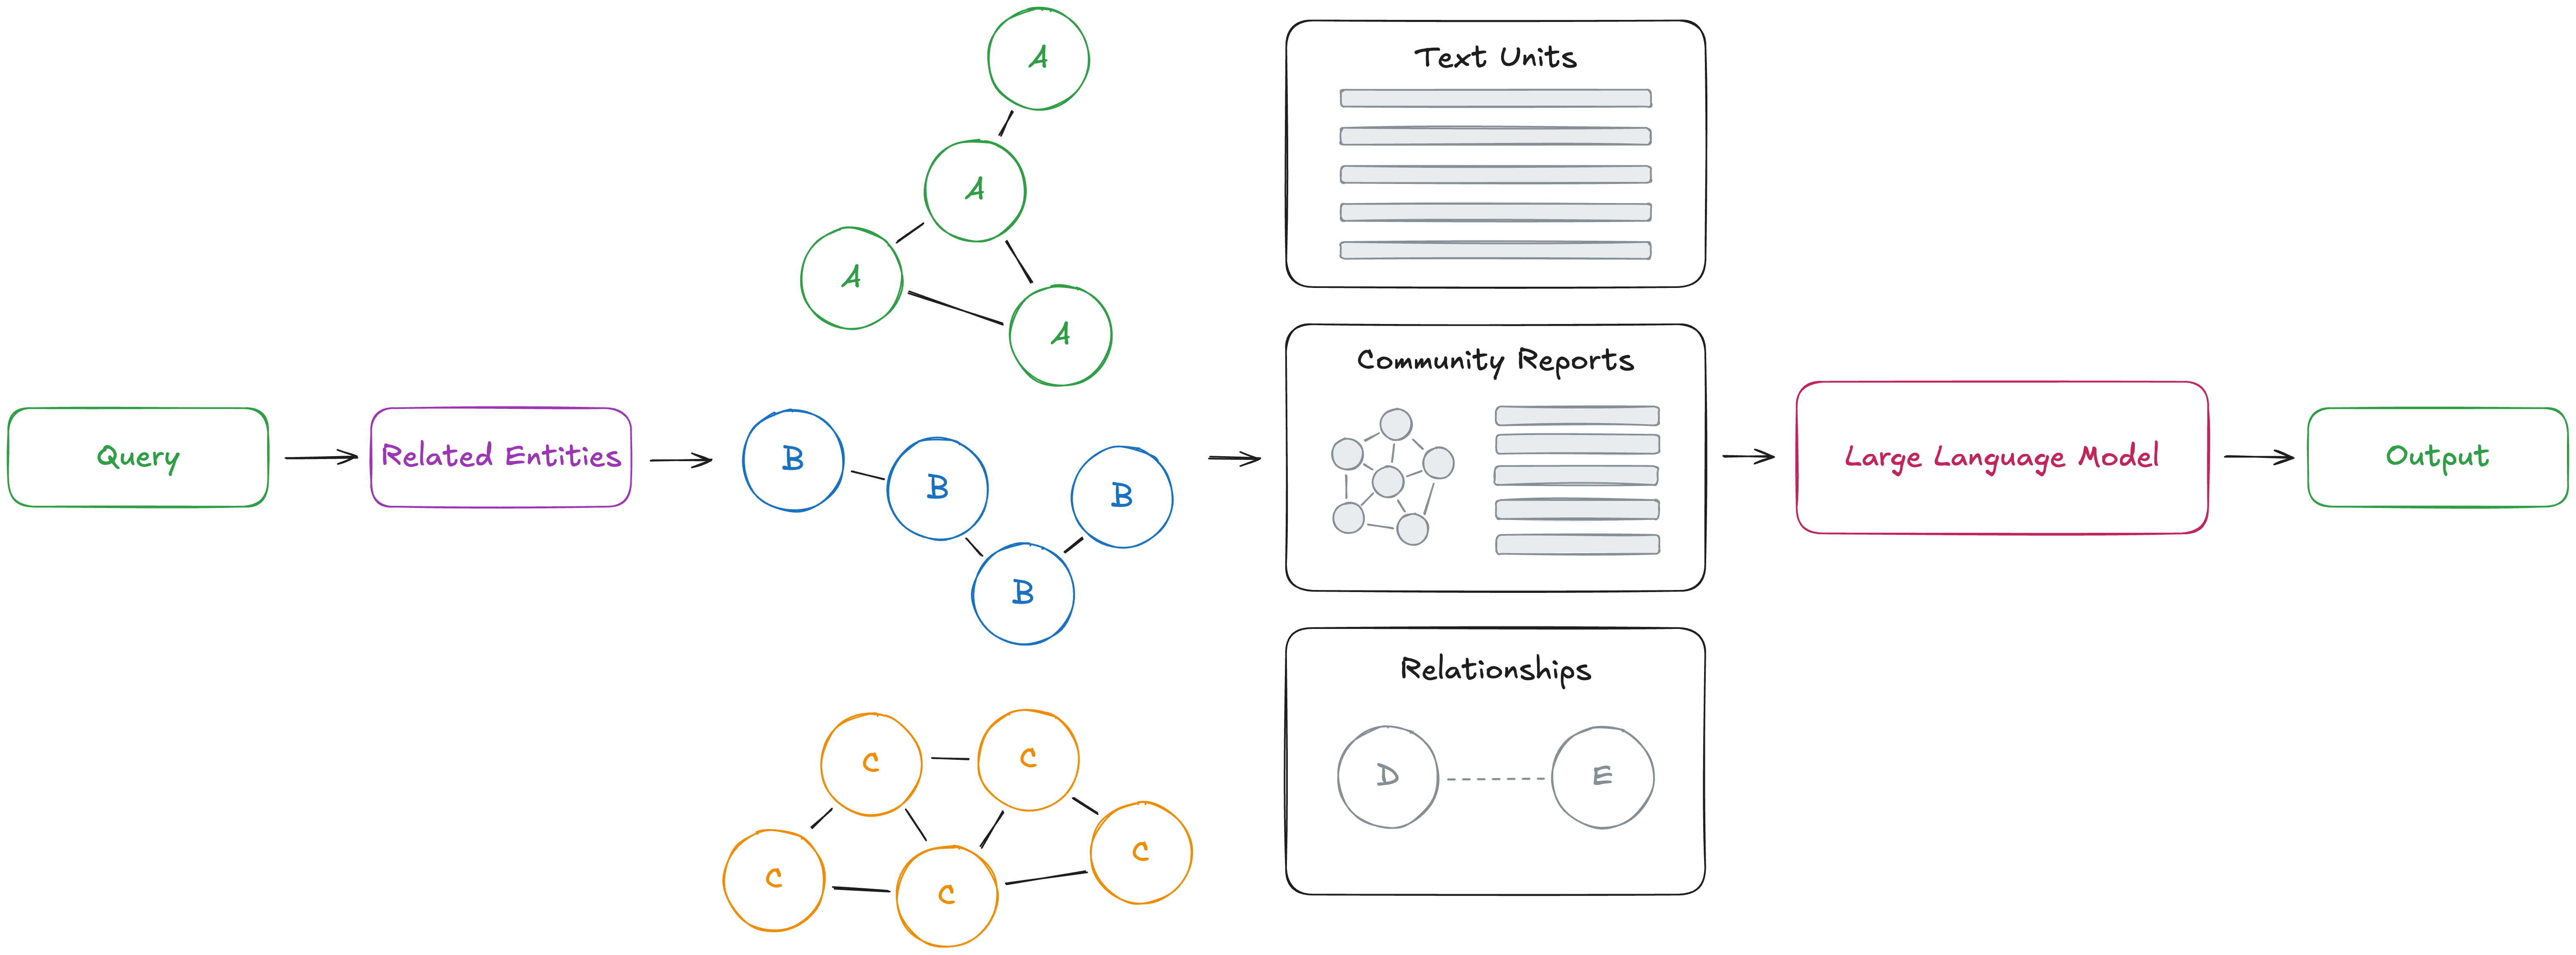

**まず一言で**
ローカル検索は、**クエリに近い“登場人物や概念”を起点に**、その周辺をたどって**根拠のある答え**をつくるやり方。
普通のベクタRAGに似ているけど、**知識グラフ（誰→誰→何の関係）**も一緒に使うので、**因果や相互作用**が説明しやすいのが強みです。

**どう動くか（3ステップ）**

1. **入口さがし**：クエリに近いエンティティ（例：K、先生）や文チャンクをセマンティック検索で拾う。
2. **周辺をたどる**：入口から1〜2ホップだけ、**関係**・**関連エンティティ**・**原文スニペット**・**コミュニティ要約**を集める。
3. **要点を詰める**：重複を減らし、**根拠→説明**の順でLLMに渡してコンテキスト内にきれいに収める。

**得意なこと**

* 「誰が・誰に・なぜ」を**関係経路で説明**する
* **引用や具体例**を出しながら答える（根拠がはっきり）

**苦手になりやすいこと**

* クエリが**すごく曖昧**だと入口が外れてしまう

  * → そのときは先に**グローバル検索**で全体像をつかんでからローカルに落とすと安定

---

#### 技術メモ（最小限）

* **入口候補**：埋め込み類似度で `entities / text_units / community_reports` から上位k件を取得
* **近傍探索**：1–2 hop で `entity ↔ relation ↔ text` を収集、`relation_strength` や `degree` で重み付け
* **パッキング**：

  * 優先順：**原文スニペット** → **関係説明（誰→誰→何）** → **短い要約**
  * 余ったら圧縮（要約）してトークン予算に収める
* **日本語のコツ**：エンティティの**内部キーは英大文字**（表記ゆれ対策）、`chunk_overlap≈200` で文脈切断を緩和

---

#### 例（文学の質問なら）

> 「Kが自殺に至った主要動機と、その後『先生』『お嬢さん』『語り手』へ与えた影響は？」

* 入口：`K`, `先生`, `お嬢さん`, `語り手`, `嫉妬`, `罪悪感`
* 回答は、**原文の抜粋**＋**関係のつながり**を根拠に、
  **動機 → 行為 → 影響**の順で簡潔にまとめる。


In [33]:
result = query_graphrag(
    query=query,
    method="local"
)
print("Query result:")
print(result)

python(3330) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Query result:
Kの自殺の主な動機は、彼が抱えていた内面的な葛藤と複雑な人間関係に起因しています。Kは、宗教的および哲学的な興味を持ちながらも、社会的なつながりを築くのが難しい人物でした。彼の「錆びた心」は、社会的な孤立感や親しい友人の欠如を示しており、これが彼の内面的な苦悩を深めたと考えられます。また、養家との関係の悪化や実家との緊張も、彼の精神的な負担を増大させました。最終的に、これらの要因が重なり合い、彼は自ら命を絶つ決断をしました [Data: Reports (1); Entities (158)]。

Kの自殺は「先生」に深い影響を与えました。「先生」はKの死を通じて、自身の人生や人間関係を見つめ直すきっかけを得ます。Kの死後、「先生」は彼の墓を訪れることを通じて、毎月の懺悔を新たにし、Kとの関係を振り返る時間を持ちます。この行動は、「先生」がKの死を通じて自らの内面を探求し続けていることを示しています [Data: Entities (4, 230)]。

一方、語り手にとってもKの自殺は大きな衝撃を与えました。語り手はKとの思い出を振り返り、彼の死がもたらした感情的な影響を深く感じています。Kの死は語り手にとって、人生の意味や人間関係の複雑さを再考する契機となり、彼の内面的な成長に寄与しました [Data: Reports (1); Entities (3)].



### グローバル検索（Global Search）
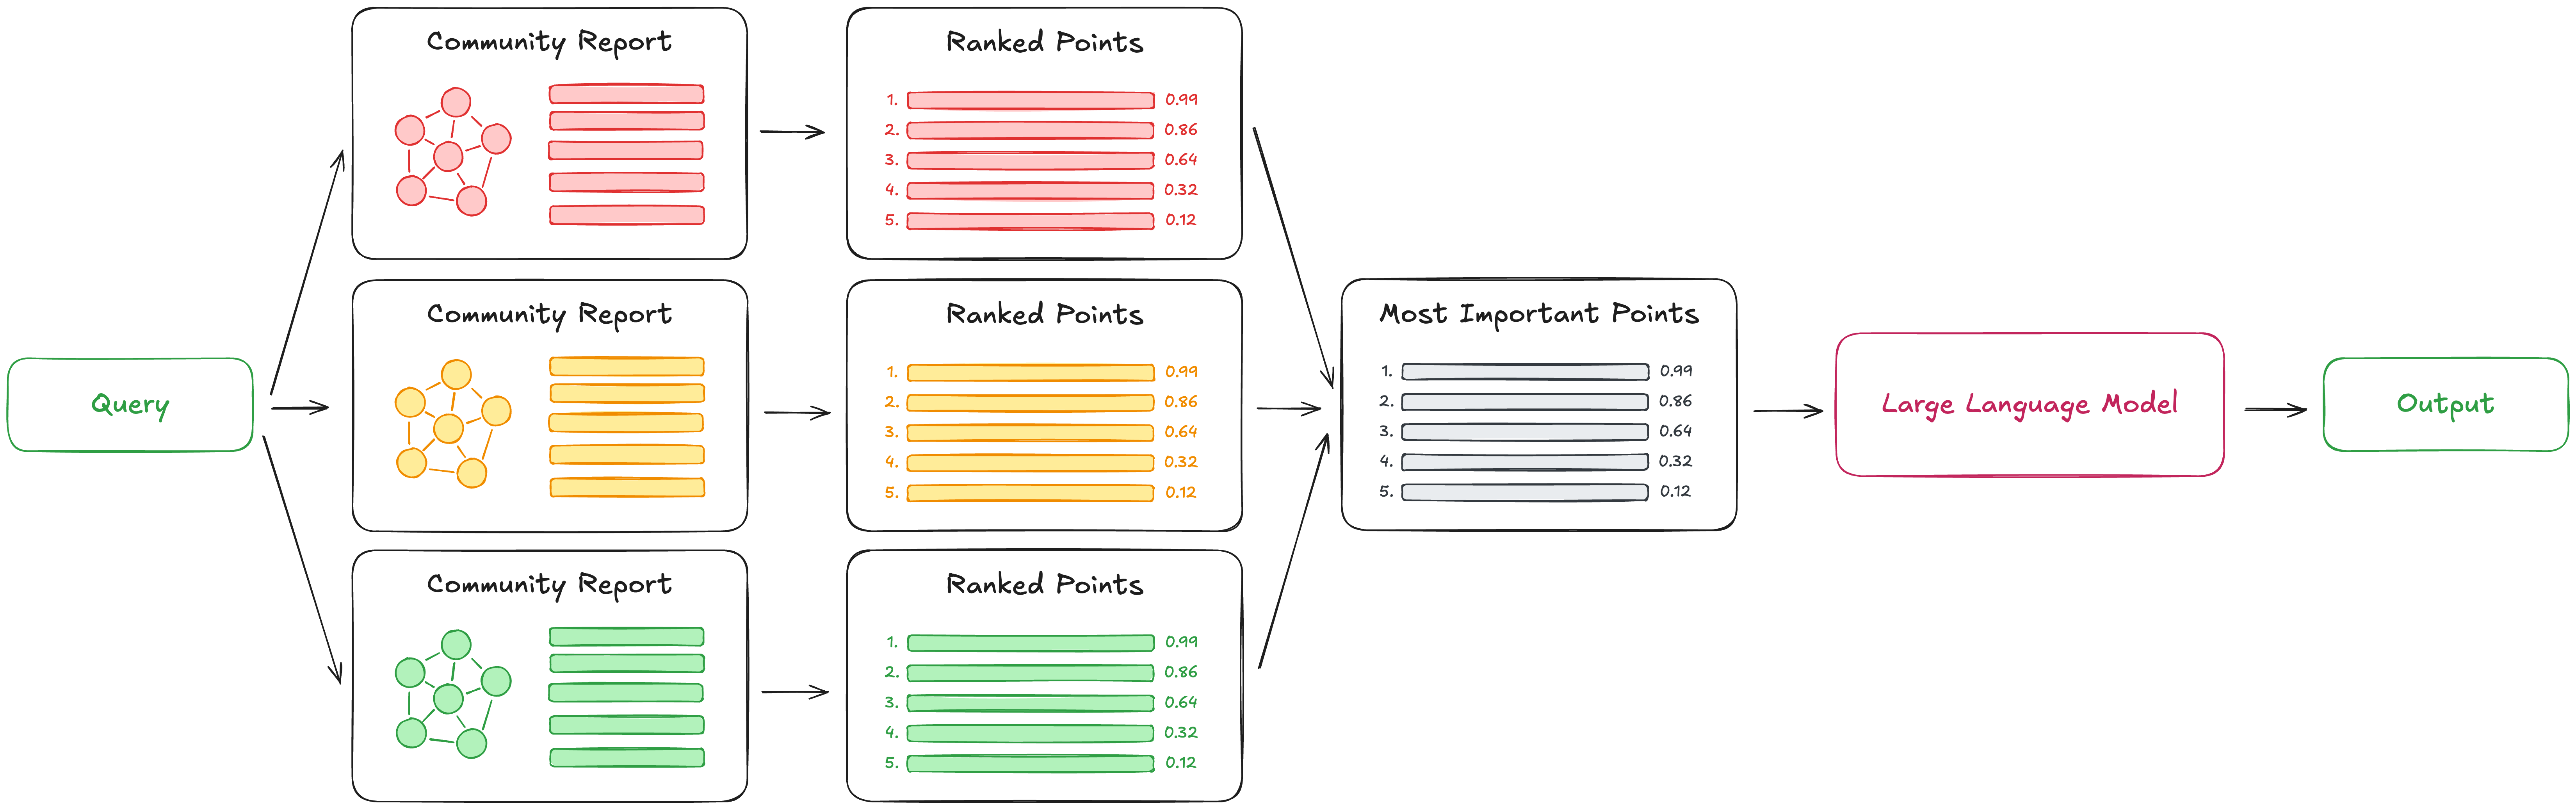
**まず一言で**
インデックス時に、コミュニティ（テーマのまとまり）ごとに**LLMで要約レポート**を作りましたよね。
グローバル検索は、その**コミュニティ要約**をうまく使って、**広いテーマ**や**抽象的な問い**に強い回答を作る手法です。
普通のベクタRAGが苦手な「全体像」「横断的な話題」を**階層レベル別レポート**でカバーします。

**どう動くか（4ステップ）**

1. **関連レベルを決める**：コミュニティ階層（例：レベル1〜2）を指定。
2. **レポート取得**：クエリに近い**コミュニティ要約**をそのレベルから集める。
3. **マップリデュース集約**：要約を**シャッフル＆小分割**→各チャンクから**重要点のリスト**を出す→**重要度スコア**で選別。
4. **最終回答**：残った**要点（中間結果）**をひとまとめの**コンテキスト**として LLM に渡し、**俯瞰的で整理された**答えを生成。

**得意なこと**

* **広いテーマ／概論／背景整理**に強い（横断まとめが上手い）
* チャンク境界に依存せず、**重要点の蒸留**ができる

**苦手になりやすいこと**

* **具体的な引用や細部の根拠**はやや弱い

  * → 細部を詰めたいときは、この後に**ローカル検索**で根拠を掘ると良い

---

#### 技術メモ（最小限）

* **入力**：ユーザ質問、`community_level`（例：2）、必要なら `--dynamic-community-selection`
* **選別**：コミュニティ要約（`community_reports`）を**埋め込み類似度**で取得
* **マップリデュース**：

  * **Map**：チャンクごとに**要点候補（bullet）＋重要度スコア**を生成
  * **Reduce**：全候補を**ランク付け＆去重（MMR）**して上位だけ保持
* **コンテキスト**：残った要点を**中間集約**として LLM に渡し、最終回答を出す
* **チューニング**：`community_level` を上げる→抽象度↑、下げる→具体性↑。**1〜2**を起点に比較が吉

---

#### 例（文学の質問なら）

> 「『こころ』における主要テーマの全体像は？」

* レベル1〜2のコミュニティ要約を拾い、**道徳的葛藤／罪責／愛と嫉妬／近代的自我**といった**上位テーマ**をまず整理。
* その上で、必要に応じて**ローカル検索**で人物関係や具体場面の根拠を掘り下げる二段構えが効果的。

---

#### 使い分けの目安

* **グローバル**：まず**全体像**・**横断的な論点**を掴む
* **ローカル**：**根拠**・**引用**・**因果の具体**を詰める
* **DRIFT**：問いが曖昧／広いときに**探索しながら**方向付け

---

※ 実装はこれまでの関数と同じで、`method="global"` と **`community_level`** を指定すればOK。
返ってきた要約系の中間ポイント群（ログに出ることが多い）を眺めると、**どのコミュニティの何が“重要”と評価されたか**が分かり、調整のヒントになります。


In [34]:
result = query_graphrag(
    query=query,
    method="global"
)
print("Query result:")
print(result)

python(3676) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Query result:
## Kの自殺の主な動機

Kの自殺の主な動機は、彼の内面的な葛藤や孤独感、そして社会的な疎外感に起因しています。Kは仏教の教えに影響を受け、独立心と誇りを持っていましたが、社会的なつながりの欠如が彼の心に影を落としていました [Data: Reports (16, 158, 314, 315)]。また、彼は哲学的・宗教的な興味を持ち、社会的な期待と個人的な信念の間で葛藤していました [Data: Reports (1, 17, 33, 6, 18)]。さらに、語り手の婚約の知らせが彼に影響を与えた可能性も指摘されています [Data: Reports (41, 42)]。

## 「先生」への影響

Kの自殺は「先生」に深い影響を与えました。「先生」はKの死を通じて、自らの人生観や道徳観を再評価し、罪悪感や責任感を抱くようになりました。この出来事は「先生」の人生における重要な転機となり、彼の内面的な変化を促しました [Data: Reports (1, 9, 35, 8, 17)]。また、彼は自身の過去の行動や選択を再評価し、罪悪感や後悔を抱くようになり、人生観や人間関係に対する見方が変わりました [Data: Reports (38, 41)]。

## 「語り手」への影響

語り手にとって、Kの自殺は人生の無常さや人間関係の複雑さを考えさせる契機となりました。語り手は「先生」との対話を通じて、Kの死がもたらした影響を理解し、自己の成長や人生の意味を模索するようになります [Data: Reports (16, 162)]。Kの死は語り手にとって大きな衝撃であり、彼の人生における重要な転機となり、人生の儚さや人間関係の複雑さについて深く考えるようになりました [Data: Reports (41, 42)]。



### DRIFT 検索 (Dynamic Reasoning and Inference with Flexible Traversal)

まず、簡単に説明します。
DRIFT は「探索と深掘り」を行う検索手法です。

まず、クエリから仮想ドキュメント (HyDE) を作成し、関連するコミュニティを特定し、簡潔な概要 (入門書) を取得します。次に、得られたフォローアップの質問を素材として、ローカル検索を反復します。

つまり、グローバル (概要) とローカル (証拠) の間を何度も行き来することで、広い文脈と具体的な証拠を同時に構築する手法です。

---

##### 仕組み (5 つのステップ)

1. **HyDE (仮想ドキュメント)**

* ユーザーの質問に基づいて、グラフ内に含まれる可能性のあるコンテンツの **仮想ドキュメント** を生成し、埋め込みます。

2. **関連コミュニティの取得**

* 埋め込みを使用して、**上位 k 件のコミュニティレポート** を収集します。

3. **プライマー作成（軽量グローバル）**

* 取得したレポートから、**初期回答 + フォローアップ質問リスト** を作成します。

4. **反復ローカルサーチ**

* 各フォローアップ質問に対して**ローカルサーチ** を実行します。
* 新たに取得した**中間回答** から、さらに**フォローアップ質問** を生成し、**約2回の反復** を経て改良します。

5. **統合と最終回答**

* 取得した中間回答は、**均等重み** を持つマップリデュースアルゴリズムを使用して集約され、LLM に渡されて**最終回答** が生成されます。
* 出力は**質問-回答階層ツリー** として整理され、**元の質問との関連性** に基づいてランク付けされます。

---

##### 何が優れているのか？

* **曖昧な質問に強い**: まず大まかな推測を行い、その後、より深く掘り下げて**質問自体を展開**します。
* **適応型**: 検索中に発見された新しい情報に基づいて、**方向を簡単に変更**します。
* **双方向**: 全体的な**概要**とローカルな**証拠**をガイド付きで統合します。

**注記**

* **コスト/時間**は反復回数が増えるにつれて増加する傾向があります。
* 終了基準（反復回数と閾値）が適切に設定されていない場合、**冗長性**が発生する可能性があります。

---

#### 技術ノート（最小限）

* **入門**: HyDE で作成した仮想ドキュメントを埋め込む → `community_reports` から上位 k 件の結果を取得します。
* **入門**: 取得したレポートを**シャッフルして細分化** する → 各チャンクから**ポイント列 + 重要度** を生成します。
* **反復**: 以降の質問ごとに `method="local"` を実行します（**コミュニティの知識 + エンティティ/関係性** を組み合わせて使用​​します）。
* **集約**: 中間回答は **均等な重み** で map-reduce され、最終出力のために LLM に渡されます。
* **チューニング**: 最初は反復回数を **2** に制限します（公式には、将来的には報酬関数を使用してよりインテリジェントに停止できるようになると予想されています）。
`k`（コミュニティ数）または **community_level** をわずかに増やすと、より広い範囲をカバーできますが、コストも増加します。

---

#### 使用例

* **曖昧な研究課題**: 「『こころ』における「現代の自己」はどのように形成され、それは主人公たちの関係性とどのように関連しているのでしょうか？」

* **DRIFT**: まず、Primerを用いて主要な課題（自我／倫理／罪悪感／愛と嫉妬）を特定します。
* これらの課題から生じるフォローアップの質問（例：「Kと教師の倫理観の違いは何か？」「語り手はどこで変化したか？」）を、それぞれの課題ごとに検証します。
* 最後に、課題マップと要点（俯瞰図と証拠を組み合わせ）としてまとめます。

---

#### ポジショニングのガイドライン

* **グローバル**: まず、全体像を把握します。
* **ローカル**: 証拠と引用文献を確固たるものにします。
* **DRIFT**: 漠然とした、広範な、あるいは探索的な質問を用いる場合は、方向性の設定と深掘りを交互に行う必要があります。

---

※ 実装は以前の関数と同じです。`method="drift"` を指定するだけです。ログに「入門編で尋ねられた後続の質問」と「各ローカルの中間回答」が表示される場合は、それらを確認すると、検索がどのように分岐および収束したかを理解し、パラメータを調整するためのヒントを得ることができます。

In [35]:
result = query_graphrag(
    query=query,
    method="drift"
)
print("Query result:")
print(result)

python(4050) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Query result:
### Kの自殺の主な動機

Kの自殺の主な動機は、彼の内面的な葛藤と複雑な人間関係に起因しています。Kは、哲学や宗教に深い興味を持ち、キリスト教やコーランに関心を示していましたが、これらの探求が彼の精神的な安定に寄与したかどうかは不明です [Data: Sources (119)]. 彼の家庭環境もまた、彼の精神状態に影響を与えた可能性があります。養家との関係が悪化し、実家からも厳しい詰責を受けたことが、彼の孤独感を深めたと考えられます [Data: Sources (120, 121)].

さらに、Kは自分の将来に対する不安を抱えており、学問に対する情熱が次第に失われていく中で、自己の存在意義を見失っていたようです。彼は自分の進むべき道を見出せず、精神的に追い詰められていたことが示唆されています [Data: Sources (122)]. これらの要因が重なり合い、Kは最終的に自殺という選択をしたと考えられます。

### 「先生」への影響

Kの自殺は「先生」にとって非常に衝撃的な出来事であり、彼の人生観や価値観に大きな影響を与えました。「先生」はKの死を通じて自分の過去の行動を振り返り、罪悪感や後悔の念に苛まれます。Kの死後、「先生」はますます内向的になり、自己反省を繰り返すようになります。彼の人生観や人間関係に対する見方も変わり、特に人間の本質や死生観についての考えが深まります [Data: Reports (1); Sources (170, 116)].

### 「語り手」への影響

Kの自殺は「語り手」にも深い影響を与えます。「語り手」は「先生」の過去を知ることで、「先生」の内面的な苦悩や人間関係の複雑さを理解するようになります。これにより、「語り手」自身も人生や人間関係について深く考えるようになり、物語の終盤では、「先生」の影響を受けた新たな視点を持つようになります [Data: Reports (1); Sources (170, 116)].

このように、Kの自殺は物語の登場人物たちに深い影響を与え、彼らの人生観や人間関係に大きな変化をもたらしました。物語全体を通じて、Kの死は人間の孤独や内面的な葛藤、そしてそれが他者に与える影響についての深い考察を促す要素となっています。


**Traditional Vector RAG**
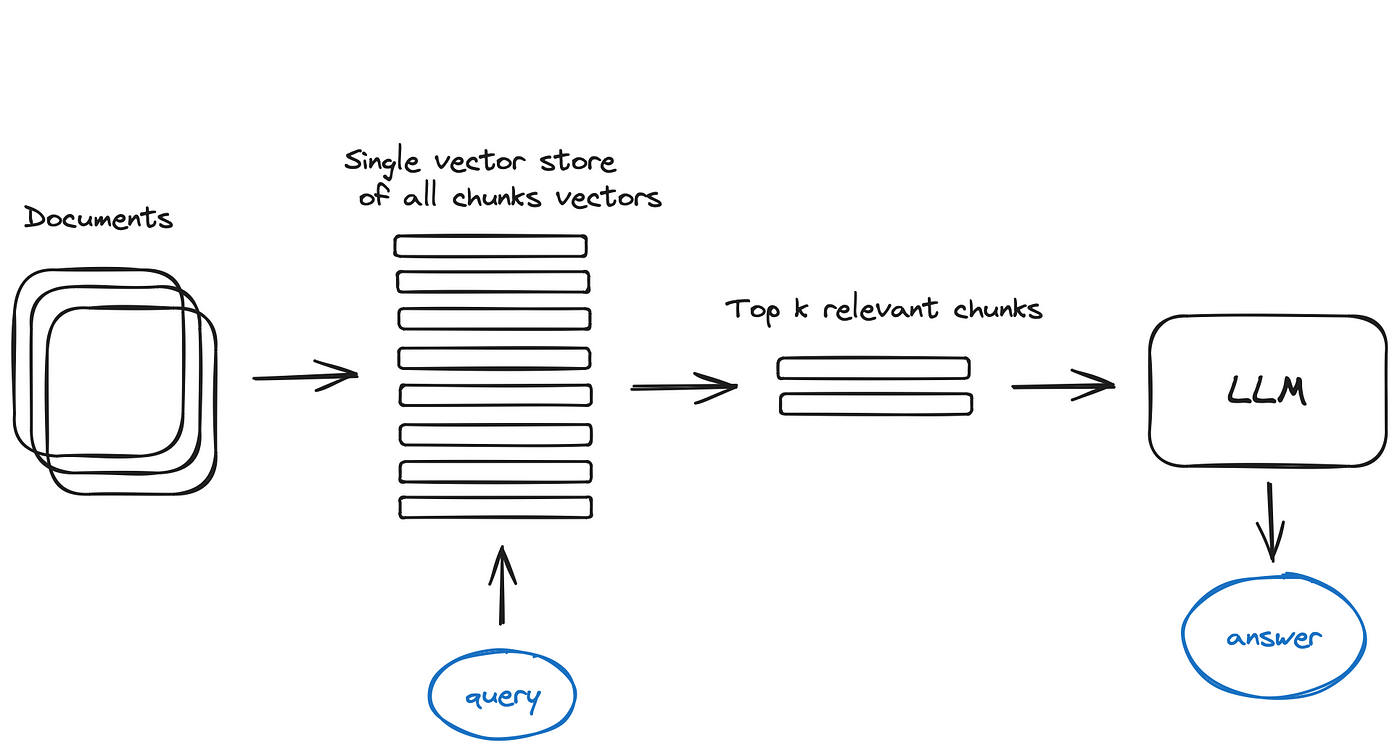

比較のために、従来のチャンク化、埋め込み、類似度検索を用いたRAGを振り返ってみましょう。

**Databaseスの初期化**

ここでは、グラフにロードされたのと同じチャンクを使用して、[ChromaDB](https://www.trychroma.com/)を使用します。

In [36]:
import chromadb 

chroma_client = chromadb.PersistentClient(path="./chromadb")
paper_collection = chroma_client.get_or_create_collection(name="paper_collection")

In [37]:
i = 0
for text in texts:
    paper_collection.add(
        documents=[text],
        ids = f"chunk_{i}"
    )
    i += 1

In [38]:
def chroma_retrieval(query, num_results=5):
    results= paper_collection.query(
    query_texts= [query],
    n_results=num_results
    )
    return results

In [39]:
rag_prompt_template = """
入力データ（以下のコンテキスト）に基づき、ユーザーの質問に答えるための
指定の長さと形式の要約回答を作成してください。必要に応じて一般知識も補足して構いません。

答えが分からない場合は、その旨を述べてください。決して捏造しないでください。

裏付けが提示されていない情報は含めないでください。

コンテキスト: {retrieved_docs}

ユーザーの質問: {query}

"""


rag_prompt = ChatPromptTemplate.from_template(rag_prompt_template)

rag_chain = rag_prompt | llm | StrOutputParser()


In [40]:
def chroma_rag(query):
    retrieved_docs = chroma_retrieval(query)["documents"][0]
    response = rag_chain.invoke({"retrieved_docs": retrieved_docs, "query": query})
    return response

In [41]:
response = chroma_rag(query)
print(response)

『こころ』のテキストに基づくと、Kが自殺した主な動機は、彼が抱えていた精神的な葛藤と孤独感に起因しています。Kは理想と現実の間で苦しみ、特に「先生」の妻に対する恋愛感情が彼の内面的な対立を深めました。Kは自分の感情を抑えきれず、またそれを「先生」に打ち明けることもできず、最終的に自殺という選択をしました。

Kの自殺は「先生」に深い影響を与えました。「先生」はKの死に対して罪悪感を抱き、自分自身の生き方や価値観を見直すきっかけとなりました。これが「先生」が後に遺書を書く動機の一つとなり、彼の人生における大きな転機となります。

語り手にとっては、「先生」の過去とKの自殺の背景を知ることで、人間の複雑な感情や倫理観について深く考える契機となりました。語り手は「先生」の遺書を通じて、人生の儚さや人間関係の難しさを学び、成長していくことになります。


### 議論（Discussion）

#### 従来型／ナイーブRAG（Traditional/Naive RAG）

**利点（Benefits）**

* **実装・運用がシンプル**：チャンク化→埋め込み→類似度検索→生成の直列パイプライン。
* **単純な情報検索に強い**：FAQ、ナレッジ検索、抜粋要約など。
* **非構造テキストに対応**：事前のスキーマ設計が不要。
* **計算コストが比較的低い**：インデクス作成と検索が軽量でスケールしやすい。

**欠点（Drawbacks）**

* **構造の消失**：チャンク化により文書間・段落間の**関係性が失われる**。
* **意味連続性の分断**：分割位置次第で関連内容が切れ、**断片化**しやすい。
* **関係把握が限定的**：人物や概念間の**多段の関係**をモデル化できない。
* **複合推論に弱い**：複数事実の**連結推論（multi-hop）**が苦手。
* **境界依存の不完全回答**：チャンク境界により**抜け落ちや重複**が生じやすい。

---

#### GraphRAG

**利点（Benefits）**

* **知識の構造保持**：エンティティ・リレーション・コミュニティ階層を**明示的に表現**。
* **関係の把握が上手い**：関連情報の**結びつき**や**多段経路**を辿れる。
* **文脈的で一貫した回答**：関係経路に基づき**背景と因果**をまとめやすい。
* **検索精度の向上**：グラフトポロジを活かした**再ランク**でノイズを減らせる。
* **複合推論への強さ**：**multi-hop**やテーマ横断の論証をサポート。
* **可読性・解釈性**：**どのノード/エッジに基づくか**を示しやすく、説明可能性が高い。

**欠点（Drawbacks）**

* **実装・保守が複雑**：抽出・統合・コミュニティ検出・要約の**前処理が多段**。
* **グラフ構築の追加コスト**：更新・再構築・一貫性管理が必要。
* **計算・ストレージ負荷**：グラフ演算やレポート生成で**オーバーヘッド**が増える。
* **ドメイン知識の関与**：スキーマやタイプ設計に**領域知見**があると有利。
* **大規模化の難度**：超大規模データでは**スケーリング戦略**が必要。

---

#### 主要な違い（Key Differentiators）

* **知識表現（Knowledge Representation）**

  * *従来RAG*：フラットな**テキストチャンク集合**。
  * *GraphRAG*：**ノード（エンティティ）—エッジ（関係）—コミュニティ（階層）**で**構造化**。

* **文脈保持（Context Preservation）**

  * *従来RAG*：分割に依存し文脈が**断片化**しやすい。
  * *GraphRAG*：関係や階層が**連続文脈**を支え、**テーマ横断**も保持。

* **推論能力（Reasoning Capability）**

  * *従来RAG*：**単発の類似度**に強いが、**多段推論**は限定的。
  * *GraphRAG*：**関係経路のトラバース**で**multi-hop推論**を支援。

* **回答品質（Answer Quality）**

  * *従来RAG*：境界で**抜け・重複**が出やすい。
  * *GraphRAG*：**構造＋要約**により、**一貫性・網羅性**が高まりやすい。

---

#### どちらを選ぶべきか（実運用の指針）

* **従来RAGが向く場合**

  * FAQ/検索支援/短文要約など、**単純な情報回収**が中心。
  * **軽量・低コスト**でスピード重視。
  * スキーマ設計やグラフ保守を避けたい。

* **GraphRAGが向く場合**

  * 人物・概念・出来事の**関係性を維持**したい（例：文芸・法律・研究レビュー）。
  * **多段推論**や**テーマ横断**が重要。
  * **説明可能性**（根拠経路・コミュニティ要約）が求められる。

**重要な注記**
GraphRAG も内部で**通常の埋め込み・類似度検索**を使います。
つまり **対立関係ではなく補完関係**。
実務では、

1. **グローバル**で全体像を掴み、
2. **ローカル**で根拠を詰め、
3. **DRIFT**で曖昧な問いを探索しながら収束、
   という**ハイブリッド運用**が最も安定します。
